In [2]:
import albatross_predictions
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('default')
mpl.rcParams['axes.linewidth'] = 7  # set the value globally
mpl.rcParams['xtick.major.size'] = 20
mpl.rcParams['xtick.major.width'] = 7
mpl.rcParams['xtick.minor.size'] = 10
mpl.rcParams['xtick.minor.width'] = 7
mpl.rcParams['ytick.major.size'] = 20
mpl.rcParams['ytick.major.width'] = 7
mpl.rcParams['ytick.labelsize'] = 50
mpl.rcParams['xtick.labelsize'] = 50
mpl.rcParams['ytick.minor.size'] = 10
mpl.rcParams['ytick.minor.width'] = 7
mpl.rcParams['font.size'] = 55
mpl.rcParams['font.sans-serif'] = 'Arial'
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['svg.fonttype'] = 'none'

In [3]:
df = albatross_predictions.get_sequence_df(r'W:\OneDrive\Virus\E1A_albatros_predictions', r'W:\OneDrive\Virus\Sequences\E1A_tilepositions.csv')

In [4]:
df

,Unnamed: 0_x,tile,start,end,sequence,PDB code,Virus,Protein,Unnamed: 0_y,length,radius_of_gyration,end_to_end_distance,scaling_exponent,asphericity,prefactor
0,0,1,1,64,MRHIICHGGVITEEMAASLLEQLIEEVLADNLPPPSHFEPPTLHEL...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.976627,60.801277,0.566122,0.463,6.407898
0,9,10,181,244,MFVYSPVSEPEPEPEPEPEPARPTRRPKMVPAILRRPTSPVSRECN...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.763824,60.652828,0.556498,0.430,6.738461
0,10,11,201,264,ARPTRRPKMVPAILRRPTSPVSRECNSSTDSCDSGPSNTPPEIHPV...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.842651,62.178566,0.563771,0.452,6.773081
0,11,12,221,284,VSRECNSSTDSCDSGPSNTPPEIHPVVPLCPIKPVAVRVGGRRQAV...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.365585,61.389832,0.567170,0.454,6.615514
0,1,2,21,84,EQLIEEVLADNLPPPSHFEPPTLHELYDLDVTAPEDPNEEAVSQIF...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.737545,64.943665,0.571103,0.451,6.638538
0,2,3,41,104,PTLHELYDLDVTAPEDPNEEAVSQIFPDSVMLAVQEGIDLLTFPPA...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.715492,63.927959,0.554926,0.442,6.406687
0,3,4,61,124,AVSQIFPDSVMLAVQEGIDLLTFPPASGSPEPPHLSRQPEQPEQRA...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.809887,62.607906,0.565833,0.450,6.826369
0,4,5,81,144,LTFPPASGSPEPPHLSRQPEQPEQRALGPVSMPNLVPEVIDLTCHE...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.465721,62.285049,0.555628,0.434,7.106082
0,5,6,101,164,QPEQRALGPVSMPNLVPEVIDLTCHEAGFPPSDDEDEEGEEFVLDY...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,23.510994,53.279842,0.549066,0.429,7.597262
0,6,7,121,184,DLTCHEAGFPPSDDEDEEGEEFVLDYVEQPGHGCRSCHYHRRNTGD...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,21.378674,49.165817,0.490446,0.369,6.896628


In [5]:
from localcider.sequenceParameters import SequenceParameters
import numpy as np
import pandas as pd

In [199]:
aromatics=['F','Y','W']
positives=['R','H','K']
negatives=['D','E']
valines=['V','V']
prolines = ['P', 'P']
charged = ['R', 'K'] + negatives
hydrophobic_r = ['A', 'V', 'L', 'I', 'M', 'P', 'F', 'W']

def countAA(sequence,group):
    count=0
    for aa in sequence:
        if aa in group:
            count +=1
    return count

def get_sequence_parameters(sequence: str) -> dict:
    FCR=SequenceParameters(sequence).get_FCR()
    NCPR=SequenceParameters(sequence).get_NCPR()
    mean_hydropathy=SequenceParameters(sequence).get_mean_hydropathy()
    kappa= SequenceParameters(sequence).get_kappa()
    SCD=SequenceParameters(sequence).get_SCD()
    fraction_disorder_promoting=SequenceParameters(sequence).get_fraction_disorder_promoting()
    countPos=SequenceParameters(sequence).get_countPos()
    countNeut=SequenceParameters(sequence).get_countNeut()
    countNeg=SequenceParameters(sequence).get_countNeg()
    countAro=countAA(sequence,aromatics)
    isoelectric_point=SequenceParameters(sequence).get_isoelectric_point()
    Omega=SequenceParameters(sequence).get_Omega()
    valine=countAA(sequence,valines)
    proline = countAA(sequence, prolines)
    charge = countAA(sequence, charged)
    hydrophobic = countAA(sequence, hydrophobic_r)
    
    charge_percent = charge/len(sequence)
    hydro_percent = hydrophobic/len(sequence)
    features = {'sequence':[sequence],
                'FCR':[FCR],
                'NCPR':[NCPR],
                'mean_hydropathy':[mean_hydropathy],
                'kappa': [np.nan] if kappa == -1 else [kappa] ,
                'SCD':SCD,
                'fraction_disorder_promoting':[fraction_disorder_promoting],     
                'countPos':[countPos],
                'countNeut':[countNeut],
                'countNeg':[countNeg],
                'countAro':[countAro],
                'isoelectric_point':[isoelectric_point],
                'Omega':[Omega],
                'valines':[valine],
                'prolines': [proline],
                'charge': [charge/len(sequence)],
                'hydrophobic': [hydrophobic/len(sequence)],
                'ch/hy-ratio': [charge_percent/hydro_percent]
               }
    
    return features

def evaluate_sequence_features(sequences: list[str])-> pd.DataFrame:
    df = pd.DataFrame()
    for i in sequences:
        new_df = pd.DataFrame(get_sequence_parameters(i))
        df = pd.concat([df, new_df], ignore_index=True)
    return df

def get_cider_predictions(df, sequence_column):
    sequences = df[sequence_column].unique().tolist()
    sequence_df = evaluate_sequence_features(sequences)
    df = pd.merge(df, sequence_df)
    return df

In [200]:
comp_df = get_cider_predictions(df, 'sequence')
comp_df = comp_df.rename(columns = {'tile': 'construct'})
comp_df = comp_df.reset_index(drop=True).iloc[:, 1:]
comp_df['construct'] = comp_df['construct'].astype(int)
comp_df

,construct,start,end,sequence,PDB code,Virus,Protein,Unnamed: 0_y,length,radius_of_gyration,...,countNeut,countNeg,countAro,isoelectric_point,Omega,valines,prolines,charge,hydrophobic,ch/hy-ratio
0,1,1,64,MRHIICHGGVITEEMAASLLEQLIEEVLADNLPPPSHFEPPTLHEL...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.976627,...,49,14,2,3.828125,0.159529,4,7,0.234375,0.484375,0.483871
1,10,181,244,MFVYSPVSEPEPEPEPEPEPARPTRRPKMVPAILRRPTSPVSRECN...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.763824,...,47,10,2,4.593750,0.207887,4,15,0.265625,0.421875,0.629630
2,11,201,264,ARPTRRPKMVPAILRRPTSPVSRECNSSTDSCDSGPSNTPPEIHPV...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.842651,...,49,4,0,12.031250,0.048379,7,12,0.234375,0.437500,0.535714
3,12,221,284,VSRECNSSTDSCDSGPSNTPPEIHPVVPLCPIKPVAVRVGGRRQAV...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.365585,...,50,9,0,4.375000,0.035333,7,9,0.218750,0.406250,0.538462
4,2,21,84,EQLIEEVLADNLPPPSHFEPPTLHELYDLDVTAPEDPNEEAVSQIF...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.737545,...,49,15,4,3.281250,0.109102,5,9,0.234375,0.531250,0.441176
5,3,41,104,PTLHELYDLDVTAPEDPNEEAVSQIFPDSVMLAVQEGIDLLTFPPA...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.715492,...,50,13,3,3.500000,0.113462,4,11,0.218750,0.484375,0.451613
6,4,61,124,AVSQIFPDSVMLAVQEGIDLLTFPPASGSPEPPHLSRQPEQPEQRA...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.809887,...,54,8,2,3.828125,0.107336,6,11,0.156250,0.546875,0.285714
7,5,81,144,LTFPPASGSPEPPHLSRQPEQPEQRALGPVSMPNLVPEVIDLTCHE...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.465721,...,48,14,3,3.609375,0.084289,4,12,0.250000,0.468750,0.533333
8,6,101,164,QPEQRALGPVSMPNLVPEVIDLTCHEAGFPPSDDEDEEGEEFVLDY...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,23.510994,...,46,14,4,4.156250,0.102596,5,7,0.281250,0.343750,0.818182
9,7,121,184,DLTCHEAGFPPSDDEDEEGEEFVLDYVEQPGHGCRSCHYHRRNTGD...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,21.378674,...,46,14,7,4.156250,0.199433,3,4,0.281250,0.281250,1.000000


In [201]:
basal_cell_df = pd.read_pickle(r'W:\OneDrive\Virus\Paper1\processed_csvs\basal_df_for_comp_figures.pkl')
basal_cell_df['construct'] = basal_cell_df['construct'].astype(int)
plot_df = pd.merge(comp_df, basal_cell_df, on='construct', how='left')

In [202]:
plot_df = plot_df.sort_values(by='construct').reset_index(drop=True)

In [203]:
plot_df

,construct,start,end,sequence,PDB code,Virus,Protein,Unnamed: 0_y,length,radius_of_gyration,...,countAro,isoelectric_point,Omega,valines,prolines,charge,hydrophobic,ch/hy-ratio,Ef,std
0,1,1,64,MRHIICHGGVITEEMAASLLEQLIEEVLADNLPPPSHFEPPTLHEL...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.976627,...,2,3.828125,0.159529,4,7,0.234375,0.484375,0.483871,0.554731,0.006780
1,2,21,84,EQLIEEVLADNLPPPSHFEPPTLHELYDLDVTAPEDPNEEAVSQIF...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.737545,...,4,3.281250,0.109102,5,9,0.234375,0.531250,0.441176,0.459215,0.009589
2,3,41,104,PTLHELYDLDVTAPEDPNEEAVSQIFPDSVMLAVQEGIDLLTFPPA...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.715492,...,3,3.500000,0.113462,4,11,0.218750,0.484375,0.451613,0.406402,0.004187
3,4,61,124,AVSQIFPDSVMLAVQEGIDLLTFPPASGSPEPPHLSRQPEQPEQRA...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.809887,...,2,3.828125,0.107336,6,11,0.156250,0.546875,0.285714,0.423920,0.011630
4,5,81,144,LTFPPASGSPEPPHLSRQPEQPEQRALGPVSMPNLVPEVIDLTCHE...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.465721,...,3,3.609375,0.084289,4,12,0.250000,0.468750,0.533333,0.360718,0.005390
5,6,101,164,QPEQRALGPVSMPNLVPEVIDLTCHEAGFPPSDDEDEEGEEFVLDY...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,23.510994,...,4,4.156250,0.102596,5,7,0.281250,0.343750,0.818182,0.408796,0.005019
6,7,121,184,DLTCHEAGFPPSDDEDEEGEEFVLDYVEQPGHGCRSCHYHRRNTGD...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,21.378674,...,7,4.156250,0.199433,3,4,0.281250,0.281250,1.000000,0.522413,0.004950
7,8,141,204,EFVLDYVEQPGHGCRSCHYHRRNTGDPDIMCSLCYMRTCGMFVYSP...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,22.163940,...,6,4.375000,0.331464,4,10,0.250000,0.359375,0.695652,0.473924,0.010541
8,9,161,224,RRNTGDPDIMCSLCYMRTCGMFVYSPVSEPEPEPEPEPEPARPTRR...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.366360,...,3,7.875000,0.317675,4,13,0.296875,0.437500,0.678571,0.473077,0.006364
9,10,181,244,MFVYSPVSEPEPEPEPEPEPARPTRRPKMVPAILRRPTSPVSRECN...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.763824,...,2,4.593750,0.207887,4,15,0.265625,0.421875,0.629630,0.399280,0.007137


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


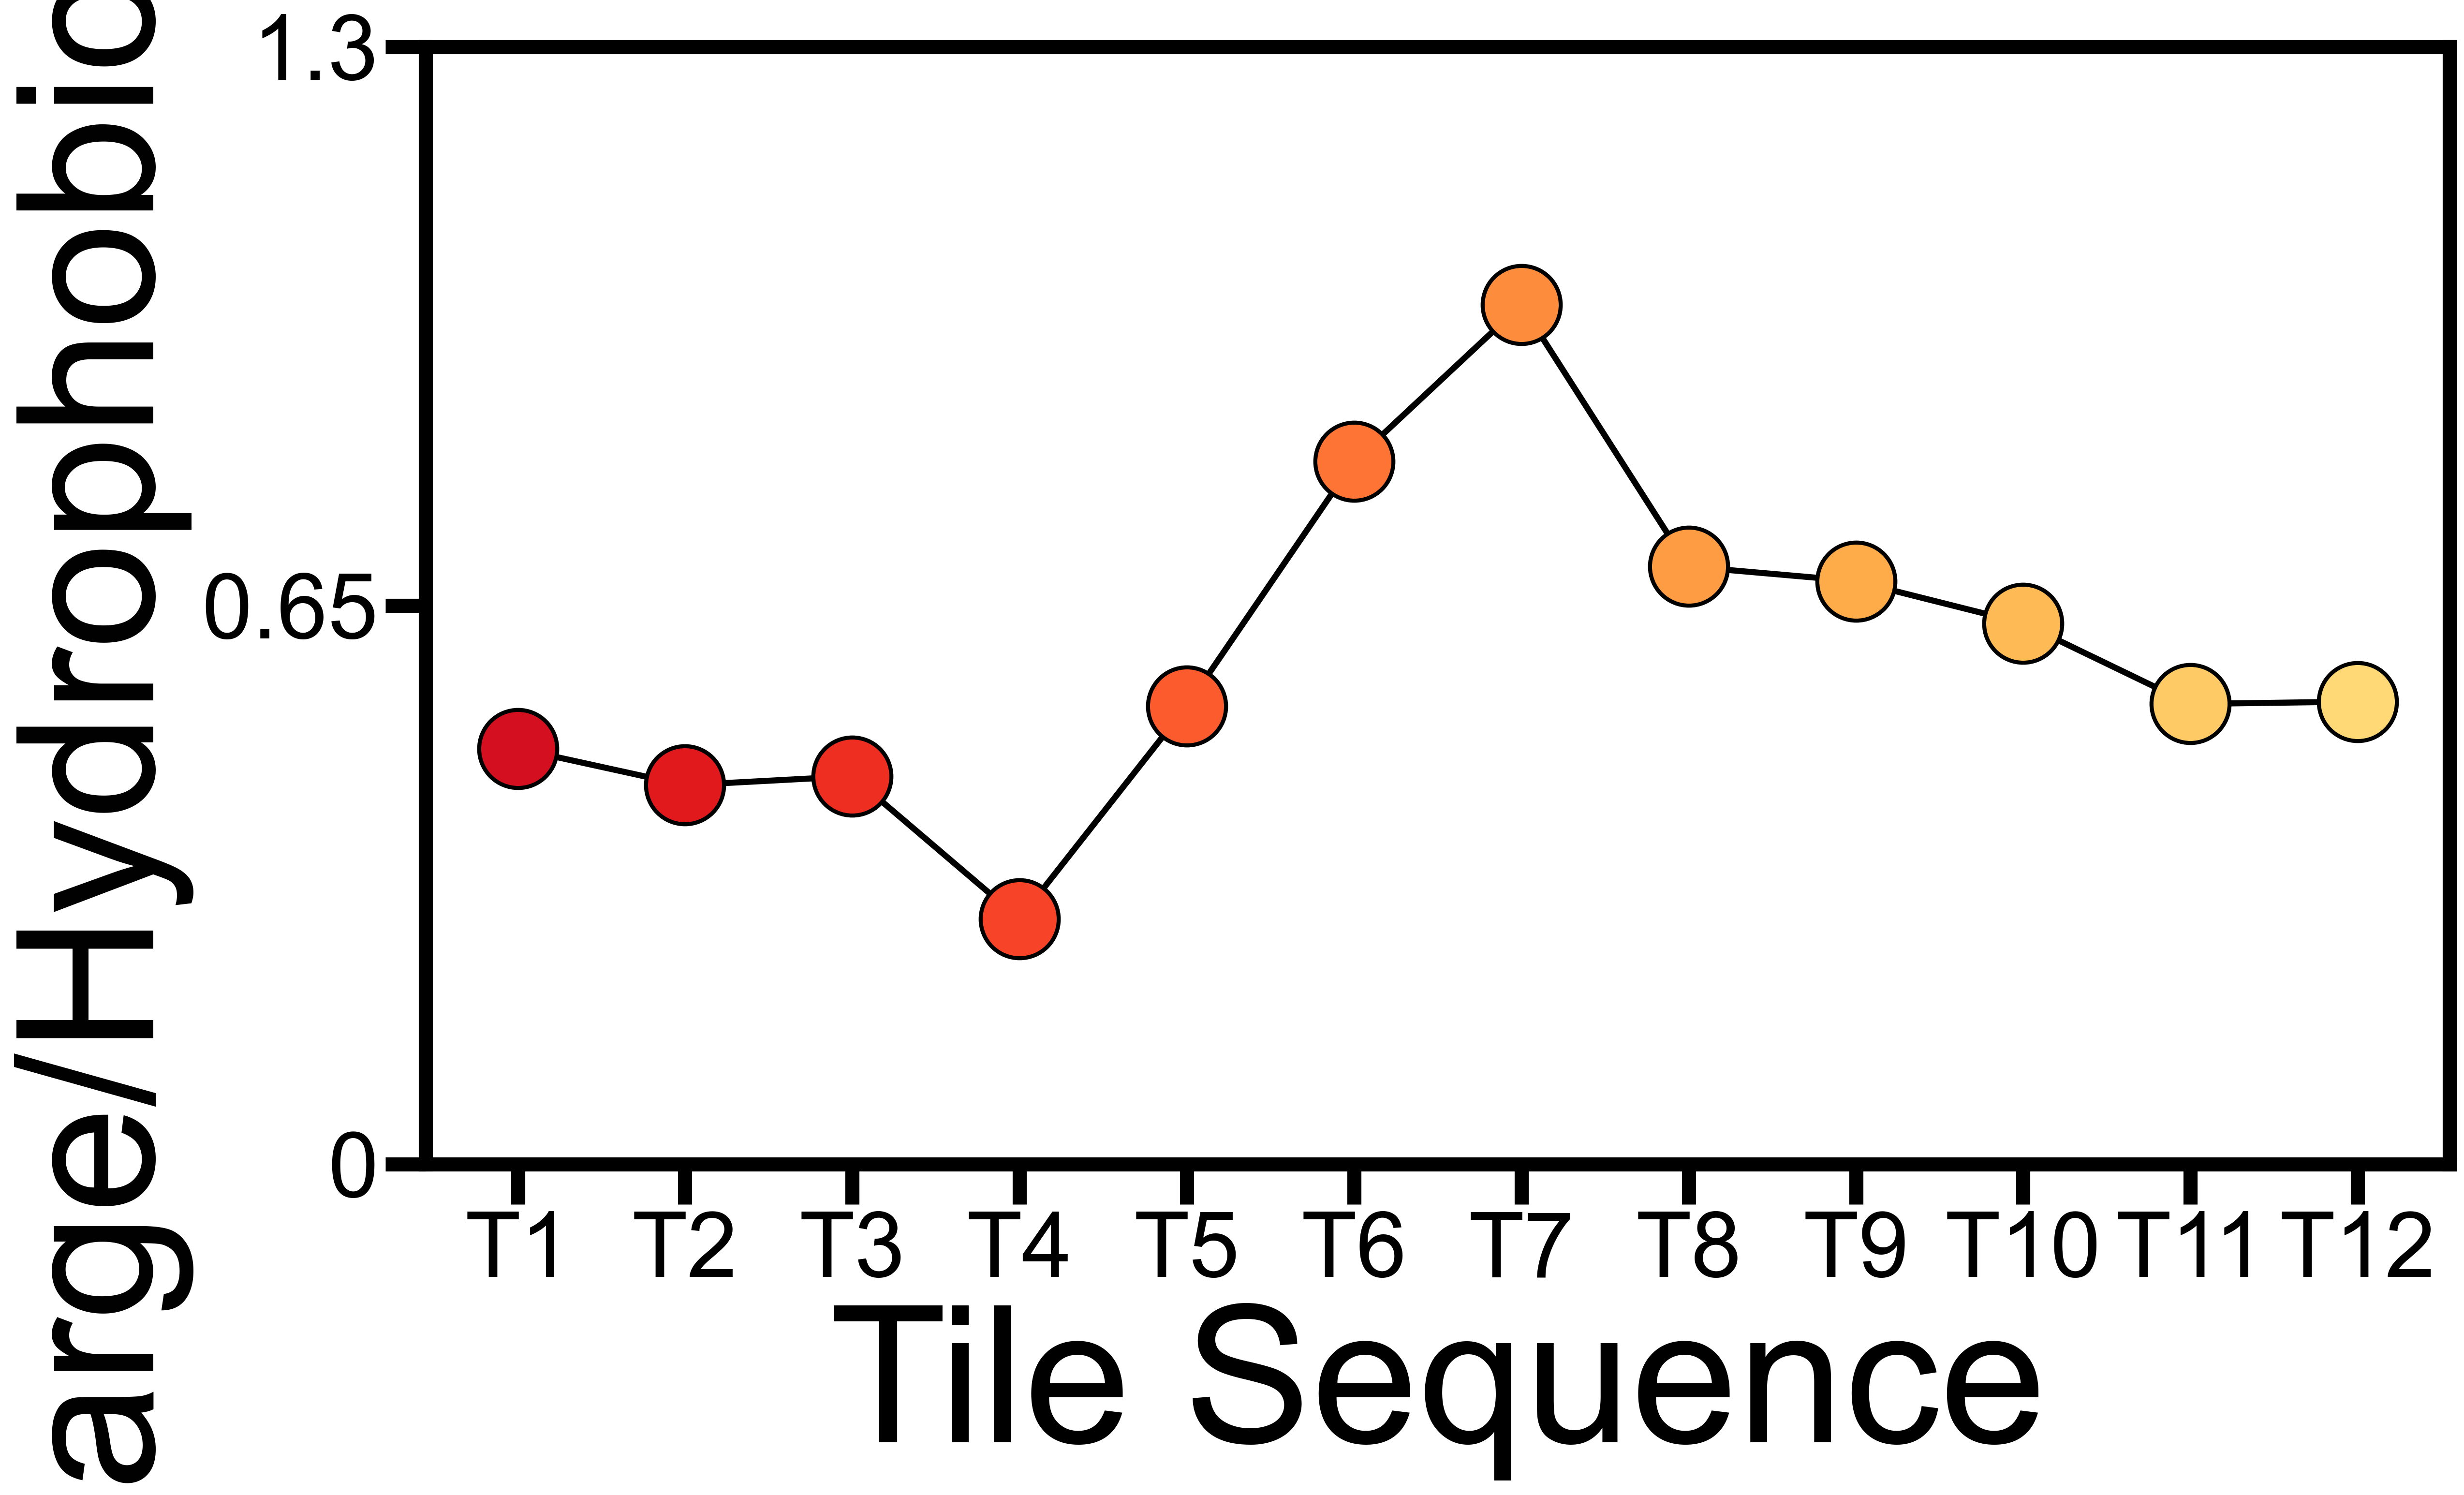

In [175]:
fig, ax = plt.subplots(figsize=(18, 10))

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.8, 0.25, N)))

xticks = []
xticks_labels = []
for i in range(12):
    pos = i+1
    xticks.append(pos)
    xticks_labels.append('T'+str(pos))
print(xticks)

x_pos =[]
y_pos = []
for i, e in plot_df.iterrows():
    s= 1500
    pos = i +1
    re = e['ch/hy-ratio']
    ax.scatter(pos, re, s=s, edgecolor='k', linewidth=2, zorder=3)
    if pos == 1:
        x_pos.append(pos)
        y_pos.append(re)
    else:
        x_pos.append(pos)
        y_pos.append(re)
        ax.plot(x_pos, y_pos, 'k', linewidth=3, zorder=1)
        x_pos = [x_pos[-1]]
        y_pos = [y_pos[-1]]

fontsize=45
yticks= [0, 0.65, 1.3]
ax.set_yticks(yticks)
ax.set_yticklabels(yticks, fontsize= fontsize)

ax.set_xticks(xticks)
ax.set_xticklabels(xticks_labels, fontsize=fontsize)

label_size = "xx-large"
ax.set_ylabel('Charge/Hydrophobic Ratio', fontsize=label_size)
ax.set_xlabel('Tile Sequence', fontsize=label_size)
plt.savefig(r'W:\OneDrive\Virus\Paper1\New_fig\computational_comparison\\chr-hy_tiles.svg' , format='svg', bbox_inches='tight')

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


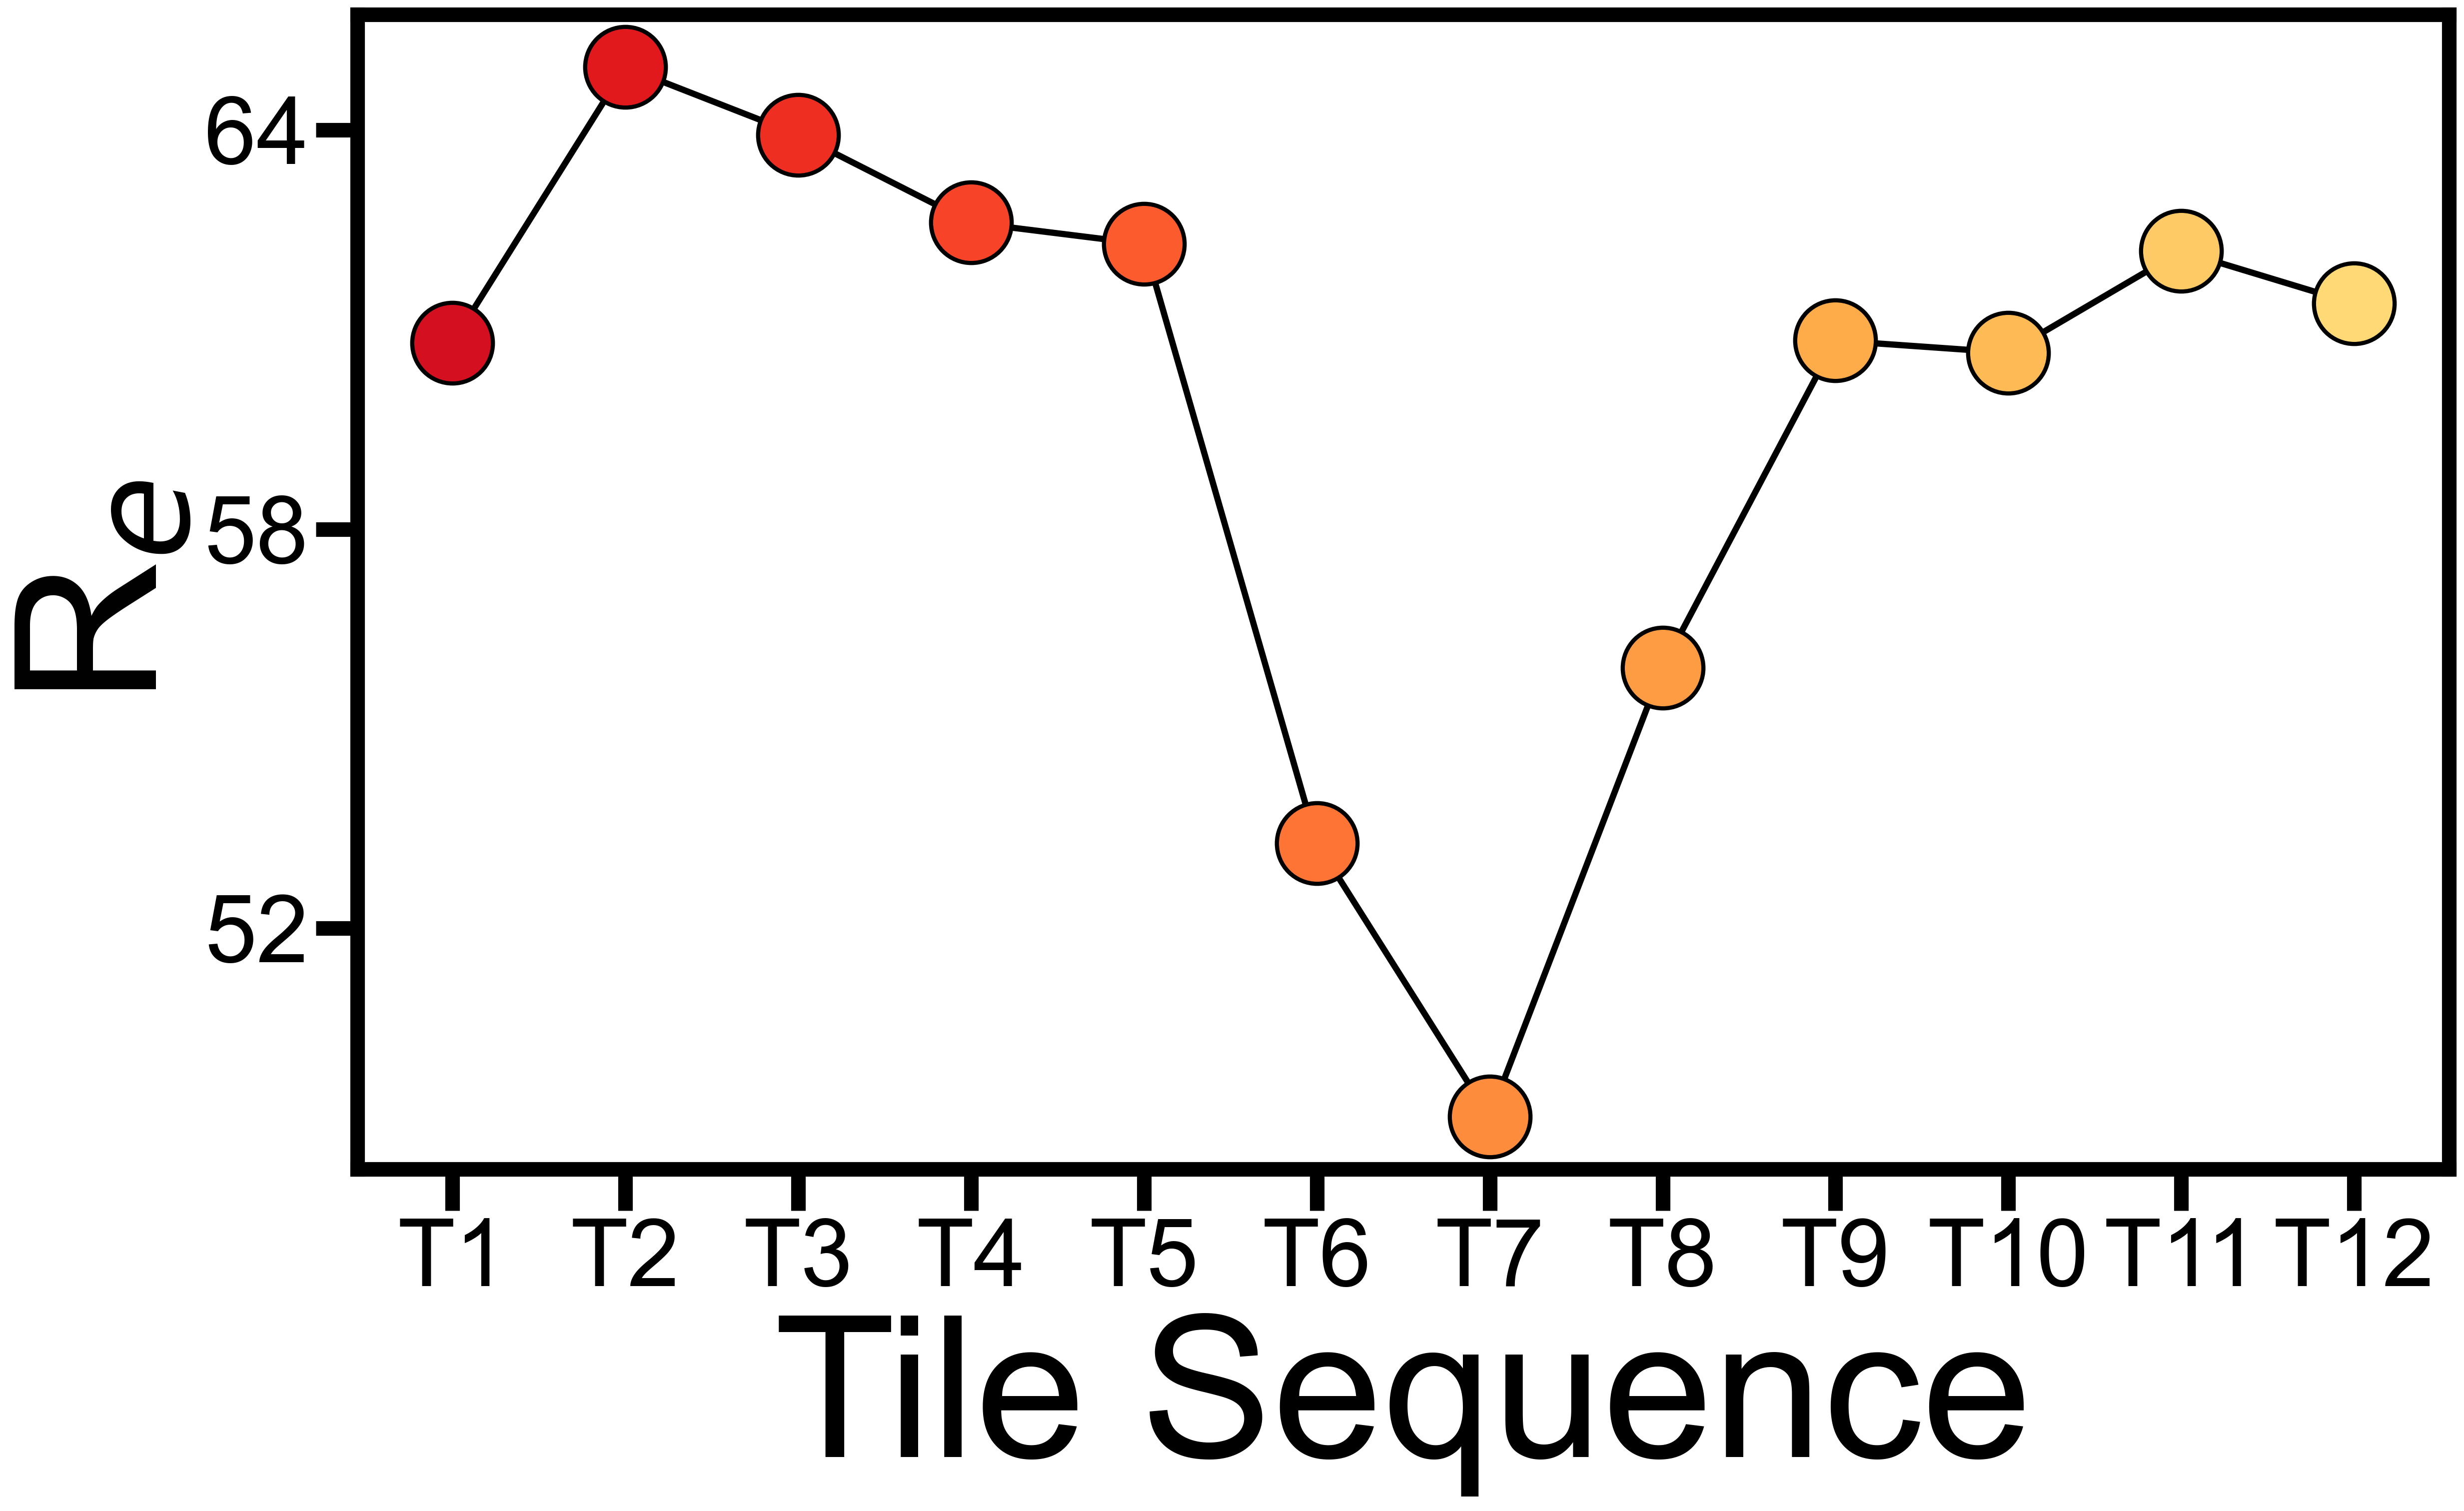

In [137]:
fig, ax = plt.subplots(figsize=(18, 10))

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.8, 0.25, N)))

xticks = []
xticks_labels = []
for i in range(12):
    pos = i+1
    xticks.append(pos)
    xticks_labels.append('T'+str(pos))
print(xticks)

x_pos =[]
y_pos = []
for i, e in plot_df.iterrows():
    s= 1500
    pos = i +1
    re = e['end_to_end_distance']
    ax.scatter(pos, re, s=s, edgecolor='k', linewidth=2, zorder=3)
    if pos == 1:
        x_pos.append(pos)
        y_pos.append(re)
    else:
        x_pos.append(pos)
        y_pos.append(re)
        ax.plot(x_pos, y_pos, 'k', linewidth=3, zorder=1)
        x_pos = [x_pos[-1]]
        y_pos = [y_pos[-1]]

fontsize=45
yticks= [52, 58, 64]
ax.set_yticks(yticks)
ax.set_yticklabels(yticks, fontsize= fontsize)

ax.set_xticks(xticks)
ax.set_xticklabels(xticks_labels, fontsize=fontsize)

label_size = "xx-large"
ax.set_ylabel('R$_e$', fontsize=label_size)
ax.set_xlabel('Tile Sequence', fontsize=label_size)
plt.savefig(r'W:\OneDrive\Virus\Paper1\New_fig\computational_comparison\\End_to_end_distance_tiles.svg' , format='svg', bbox_inches='tight')

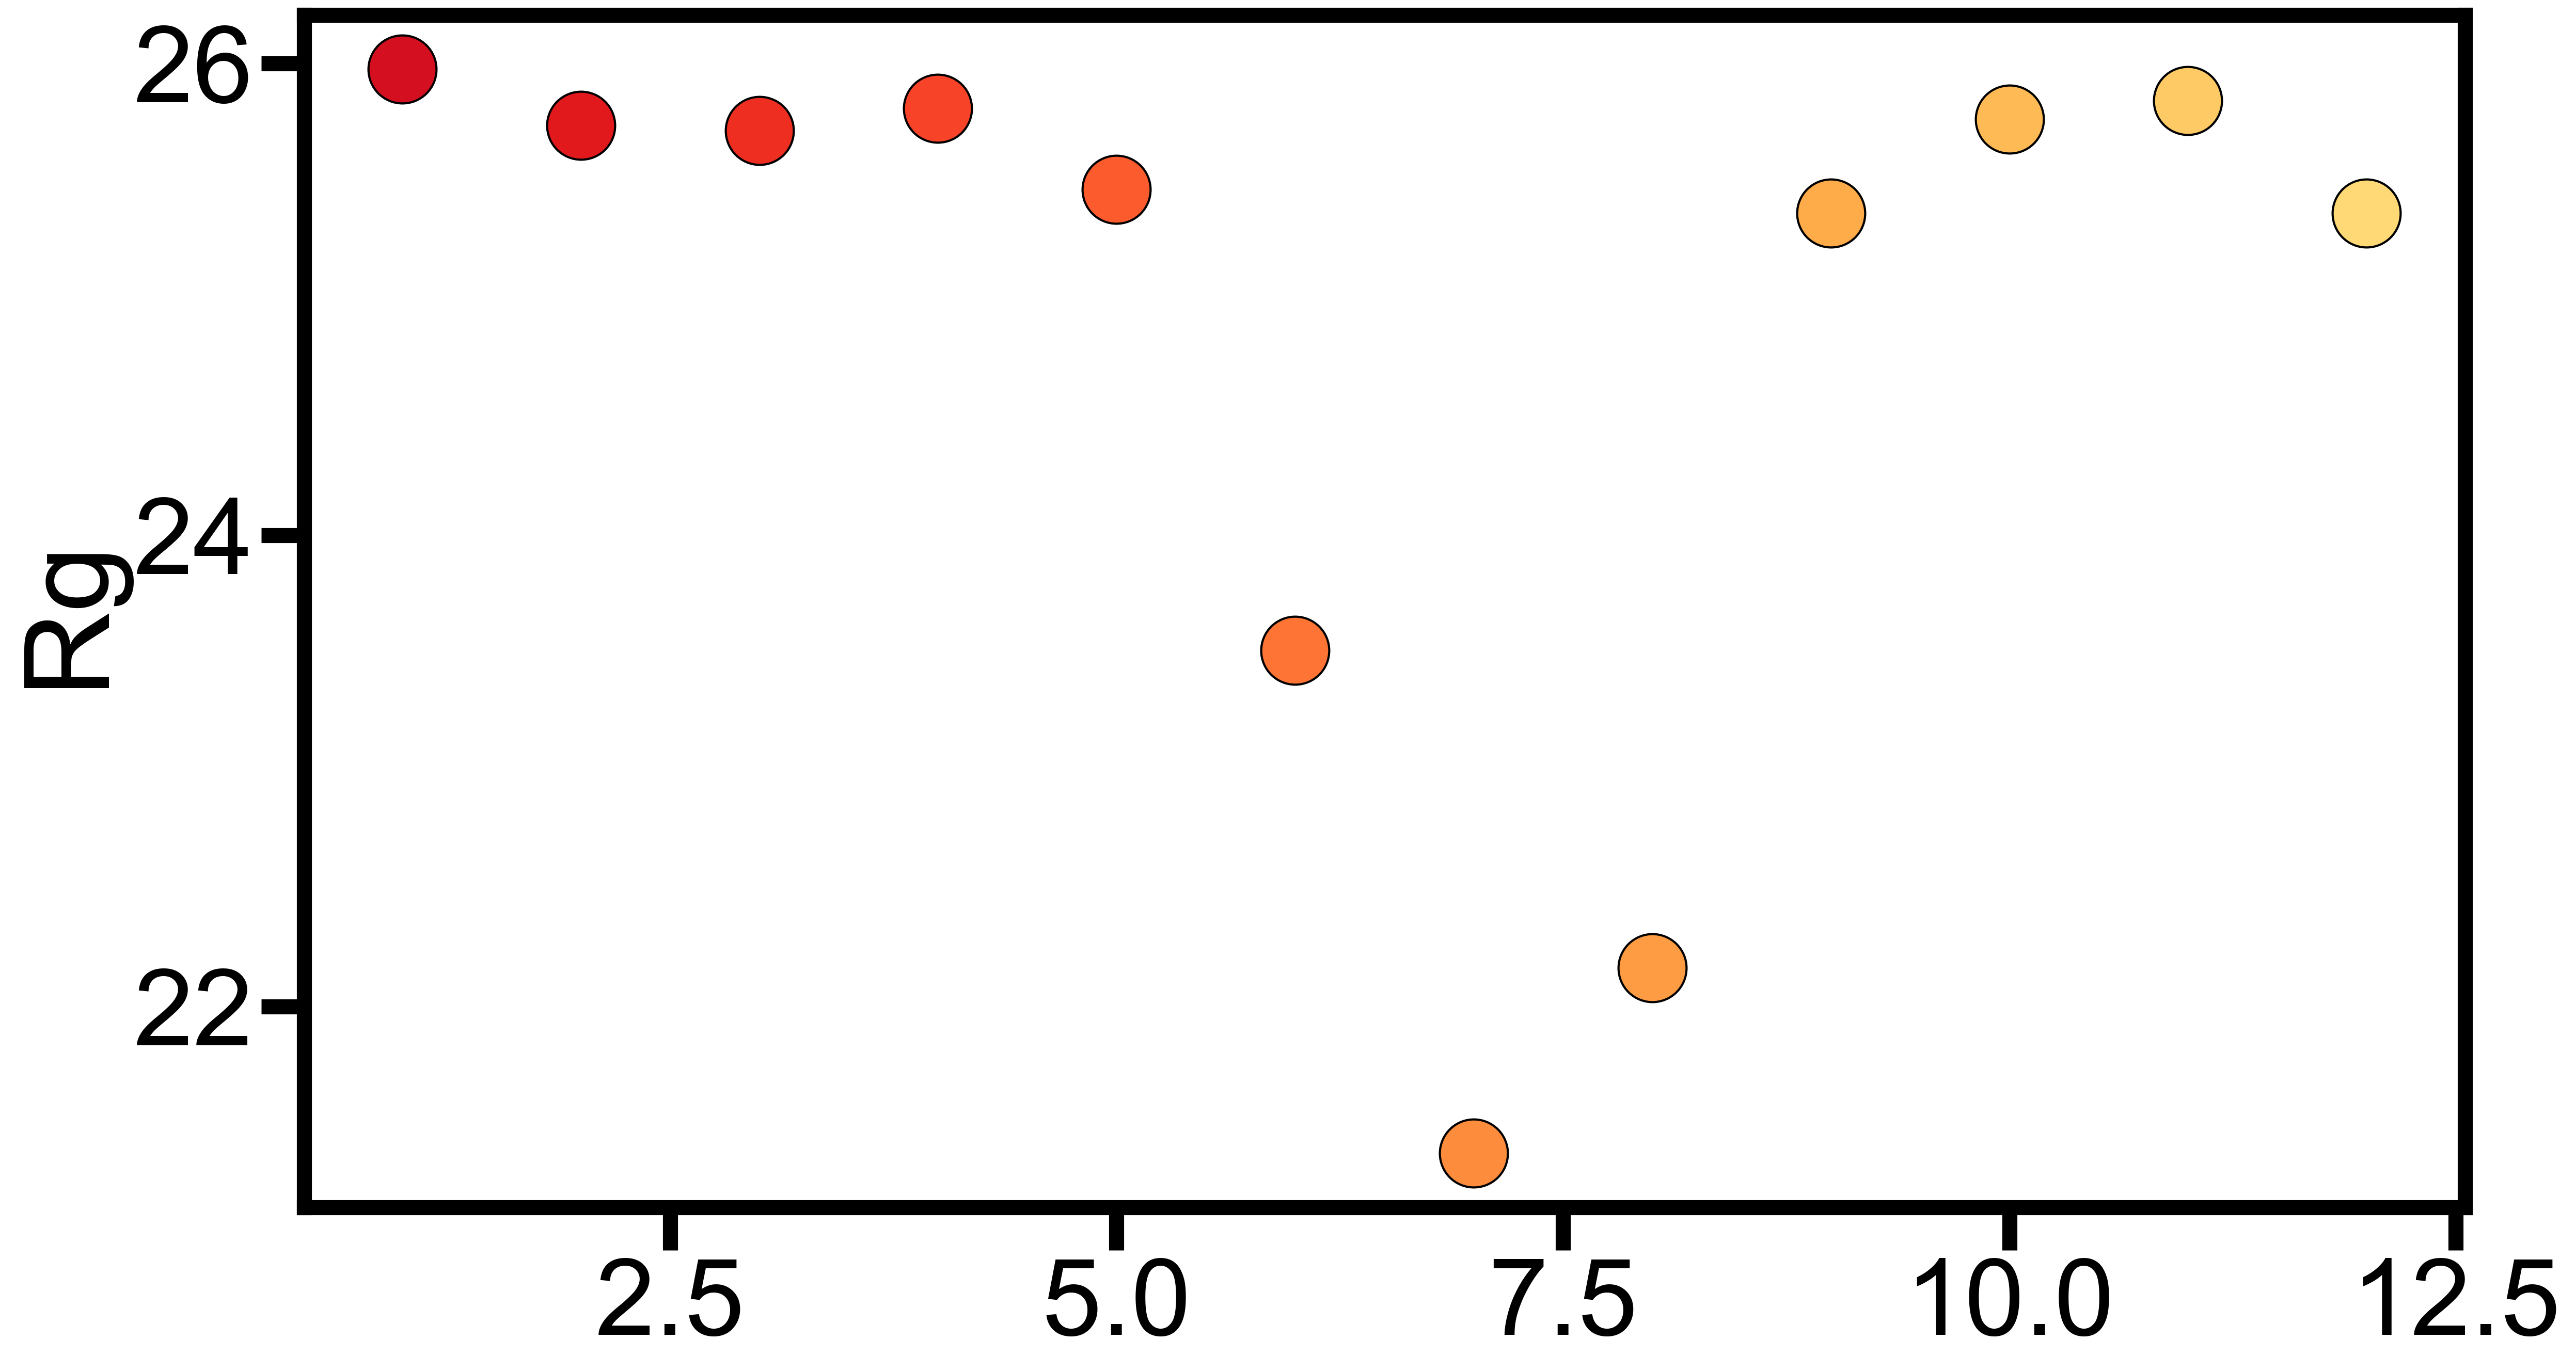

In [323]:
fig, ax = plt.subplots(figsize=(18, 10))

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.8, 0.25, N)))

for i, e in plot_df.iterrows():
    s= 1000
    pos = i +1
    re = e['radius_of_gyration']
    ax.scatter(pos, re, s=s, edgecolor='k')

ax.set_ylabel('Rg')
plt.savefig(r'W:\OneDrive\Virus\Paper1\New_fig\computational_comparison\\rg_tiles.svg' , format='svg', bbox_inches='tight')

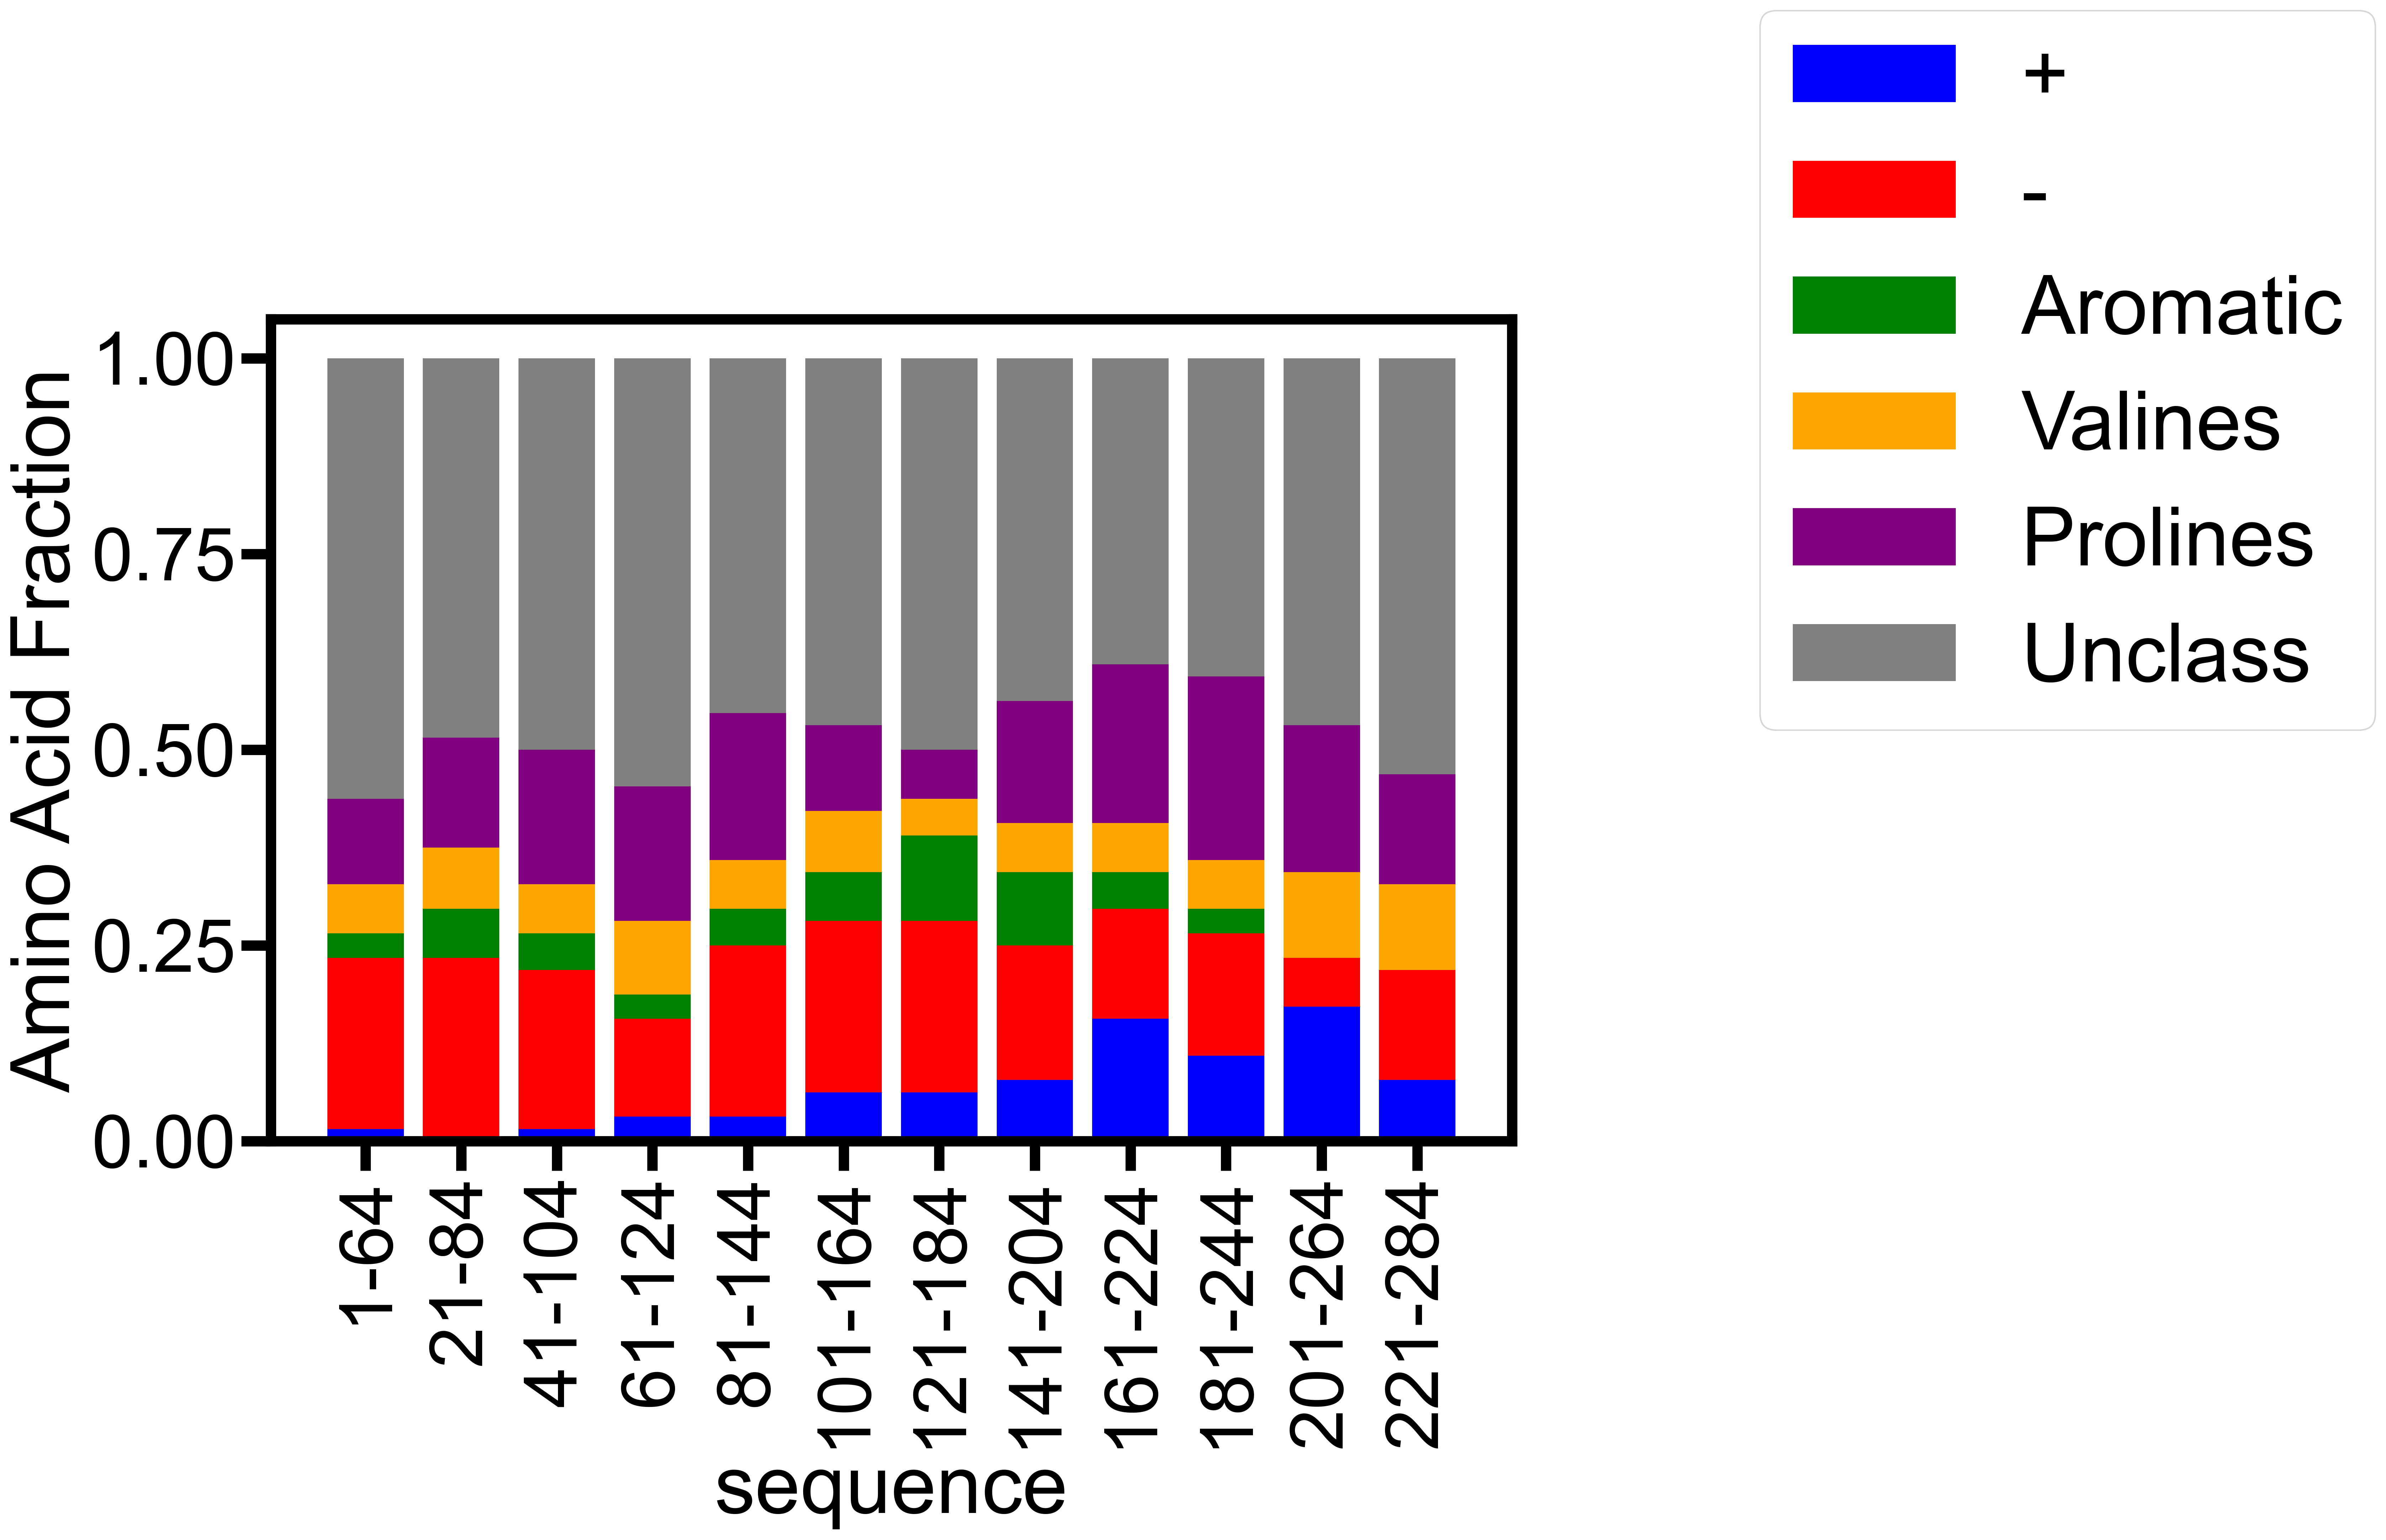

In [307]:
#Bar plot fraction of amino acids per tile
# data from https://allisonhorst.github.io/palmerpenguins/
fig, ax = plt.subplots(figsize=(15,10)) 

length =64
tiles = plot_df['construct'].unique()

bottom = np.zeros(len(tiles))

pos = np.array(plot_df['countPos'].values)
neg = np.array(plot_df['countNeg'].values)
aro = np.array(plot_df['countAro'].values)
val = np.array(plot_df['valines'].values)
pro = np.array(plot_df['prolines'].values)
neut = np.array(plot_df['countNeut'].values)


weight_counts = {'+':  pos/length,
                 '-': neg/length,
                 'Aromatic': aro/length,
                 'Valines': val/length,
                 'Prolines': pro/length,
                 'Unclass': (neut - pro - val - aro)/length,
                }

colors = {'+': 'blue',
         '-': 'red',
         'Aromatic': 'green',
         'Valines': 'orange',
         'Prolines': 'purple',
         'Unclass': 'gray',
         }

width = 0.8


for boolean, weight_count in weight_counts.items():
    p = ax.bar(tiles, weight_count, width, label=boolean, bottom=bottom, color = colors[boolean])
    bottom += weight_count

#ax.bar(tiles, 1.001, width, edgecolor='k', linewidth= 1, color='k', alpha=0)
ax.set_ylabel('Amino Acid Fraction')
ax.set_xlabel('sequence')

ax.set_xticks(tiles)
label1 = (tiles-1)*20 +1
label2 = (tiles-1)*20 +64
labels = []
for t, y in zip(label1, label2):
    labels.append(str(t)+'-'+str(y))

ax.set_xticklabels(labels, rotation=90, ha='center', va='top')

ax.legend(loc=(1.2, 0.5))
plt.savefig(r'W:\OneDrive\Virus\Paper1\New_fig\computational_comparison\aminoacid_fraction.svg' , format='svg', bbox_inches='tight')

In [385]:
plot_df

,construct,start,end,sequence,PDB code,Virus,Protein,Unnamed: 0_y,length,radius_of_gyration,...,countPos,countNeut,countNeg,countAro,isoelectric_point,Omega,valines,prolines,Efret,std
0,1,1,64,MRHIICHGGVITEEMAASLLEQLIEEVLADNLPPPSHFEPPTLHEL...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.976627,...,1,49,14,2,3.828125,0.159529,4,7,0.562914,0.024520
1,2,21,84,EQLIEEVLADNLPPPSHFEPPTLHELYDLDVTAPEDPNEEAVSQIF...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.737545,...,0,49,15,4,3.281250,0.109102,5,9,0.451020,0.026966
2,3,41,104,PTLHELYDLDVTAPEDPNEEAVSQIFPDSVMLAVQEGIDLLTFPPA...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.715492,...,1,50,13,3,3.500000,0.113462,4,11,0.412760,0.019410
3,4,61,124,AVSQIFPDSVMLAVQEGIDLLTFPPASGSPEPPHLSRQPEQPEQRA...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.809887,...,2,54,8,2,3.828125,0.107336,6,11,0.425318,0.021400
4,5,81,144,LTFPPASGSPEPPHLSRQPEQPEQRALGPVSMPNLVPEVIDLTCHE...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.465721,...,2,48,14,3,3.609375,0.084289,4,12,0.361364,0.019633
5,6,101,164,QPEQRALGPVSMPNLVPEVIDLTCHEAGFPPSDDEDEEGEEFVLDY...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,23.510994,...,4,46,14,4,4.156250,0.102596,5,7,0.410368,0.022241
6,7,121,184,DLTCHEAGFPPSDDEDEEGEEFVLDYVEQPGHGCRSCHYHRRNTGD...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,21.378674,...,4,46,14,7,4.156250,0.199433,3,4,0.524685,0.023955
7,8,141,204,EFVLDYVEQPGHGCRSCHYHRRNTGDPDIMCSLCYMRTCGMFVYSP...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,22.163940,...,5,48,11,6,4.375000,0.331464,4,10,0.477373,0.023906
8,9,161,224,RRNTGDPDIMCSLCYMRTCGMFVYSPVSEPEPEPEPEPEPARPTRR...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.366360,...,10,45,9,3,7.875000,0.317675,4,13,0.473890,0.025435
9,10,181,244,MFVYSPVSEPEPEPEPEPEPARPTRRPKMVPAILRRPTSPVSRECN...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.763824,...,7,47,10,2,4.593750,0.207887,4,15,0.402292,0.033312


In [193]:
from scipy import stats

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.8, 0.25, N)))

def plot_scatter(merged_df, x_column, y_column='Ef'):
    x= merged_df[x_column]
    y=merged_df[y_column]
    error = merged_df['std']
    #x_label = 'R$_e$'
    x_label = 'Ch/Hy Ratio'
    y_corner = x.max() - x.max()*0.11
    
    fig, ax  = plt.subplots(figsize=(10, 10))
    mpl.rcParams['figure.dpi'] = 300
    res = stats.linregress(x, y)
    ax.set_xlim([0, 1.3])
    ax.set_ylim([0.25,0.65])
    temp_x = np.array([0, 1.3])
    ax.plot(temp_x, res.intercept + res.slope*temp_x, 'k--', linewidth=5)
    for i, b, e in zip(x, y, error):
        ax.scatter(x=i, y=b, edgecolors='k', s=1100, zorder=3, linewidths=2) 
        ax.errorbar(x=i, y=b, yerr=e, c='gray', alpha=0.8, linewidth=5, zorder=4)
    
    r_squared = res.rvalue **2
    ax.tick_params(axis='both', which='major', labelsize=23)
    ax.text(y_corner, 0.61, f'R = {round(res.rvalue, 3)}', fontsize=50)

    yticks = [0.3, 0.4, 0.5, 0.6]
    #xticks = [52, 58, 64]
    xticks = [0.0, 0.6, 1.2]
    
    ax.set_yticks(yticks)
    ax.set_xticks(xticks)

    tick_fontsize = 50
    ax.set_yticklabels(yticks, fontsize=tick_fontsize)
    ax.set_xticklabels(xticks, fontsize=tick_fontsize)

    y_column = "E$_f$"
    ax.set_ylabel(y_column, fontsize='xx-large')
    ax.set_xlabel(x_label, fontsize='xx-large')
    #plt.savefig(r'W:\OneDrive\Virus\Paper1\New_fig\computational_comparison\\Efret_comparison_to_'+ x_column +'.svg' , format='svg', bbox_inches='tight')
    plt.savefig(r'W:\OneDrive\Virus\Paper1\New_fig\computational_comparison\\Efret_comparison_to_charge-hydro.svg' , format='svg', bbox_inches='tight')

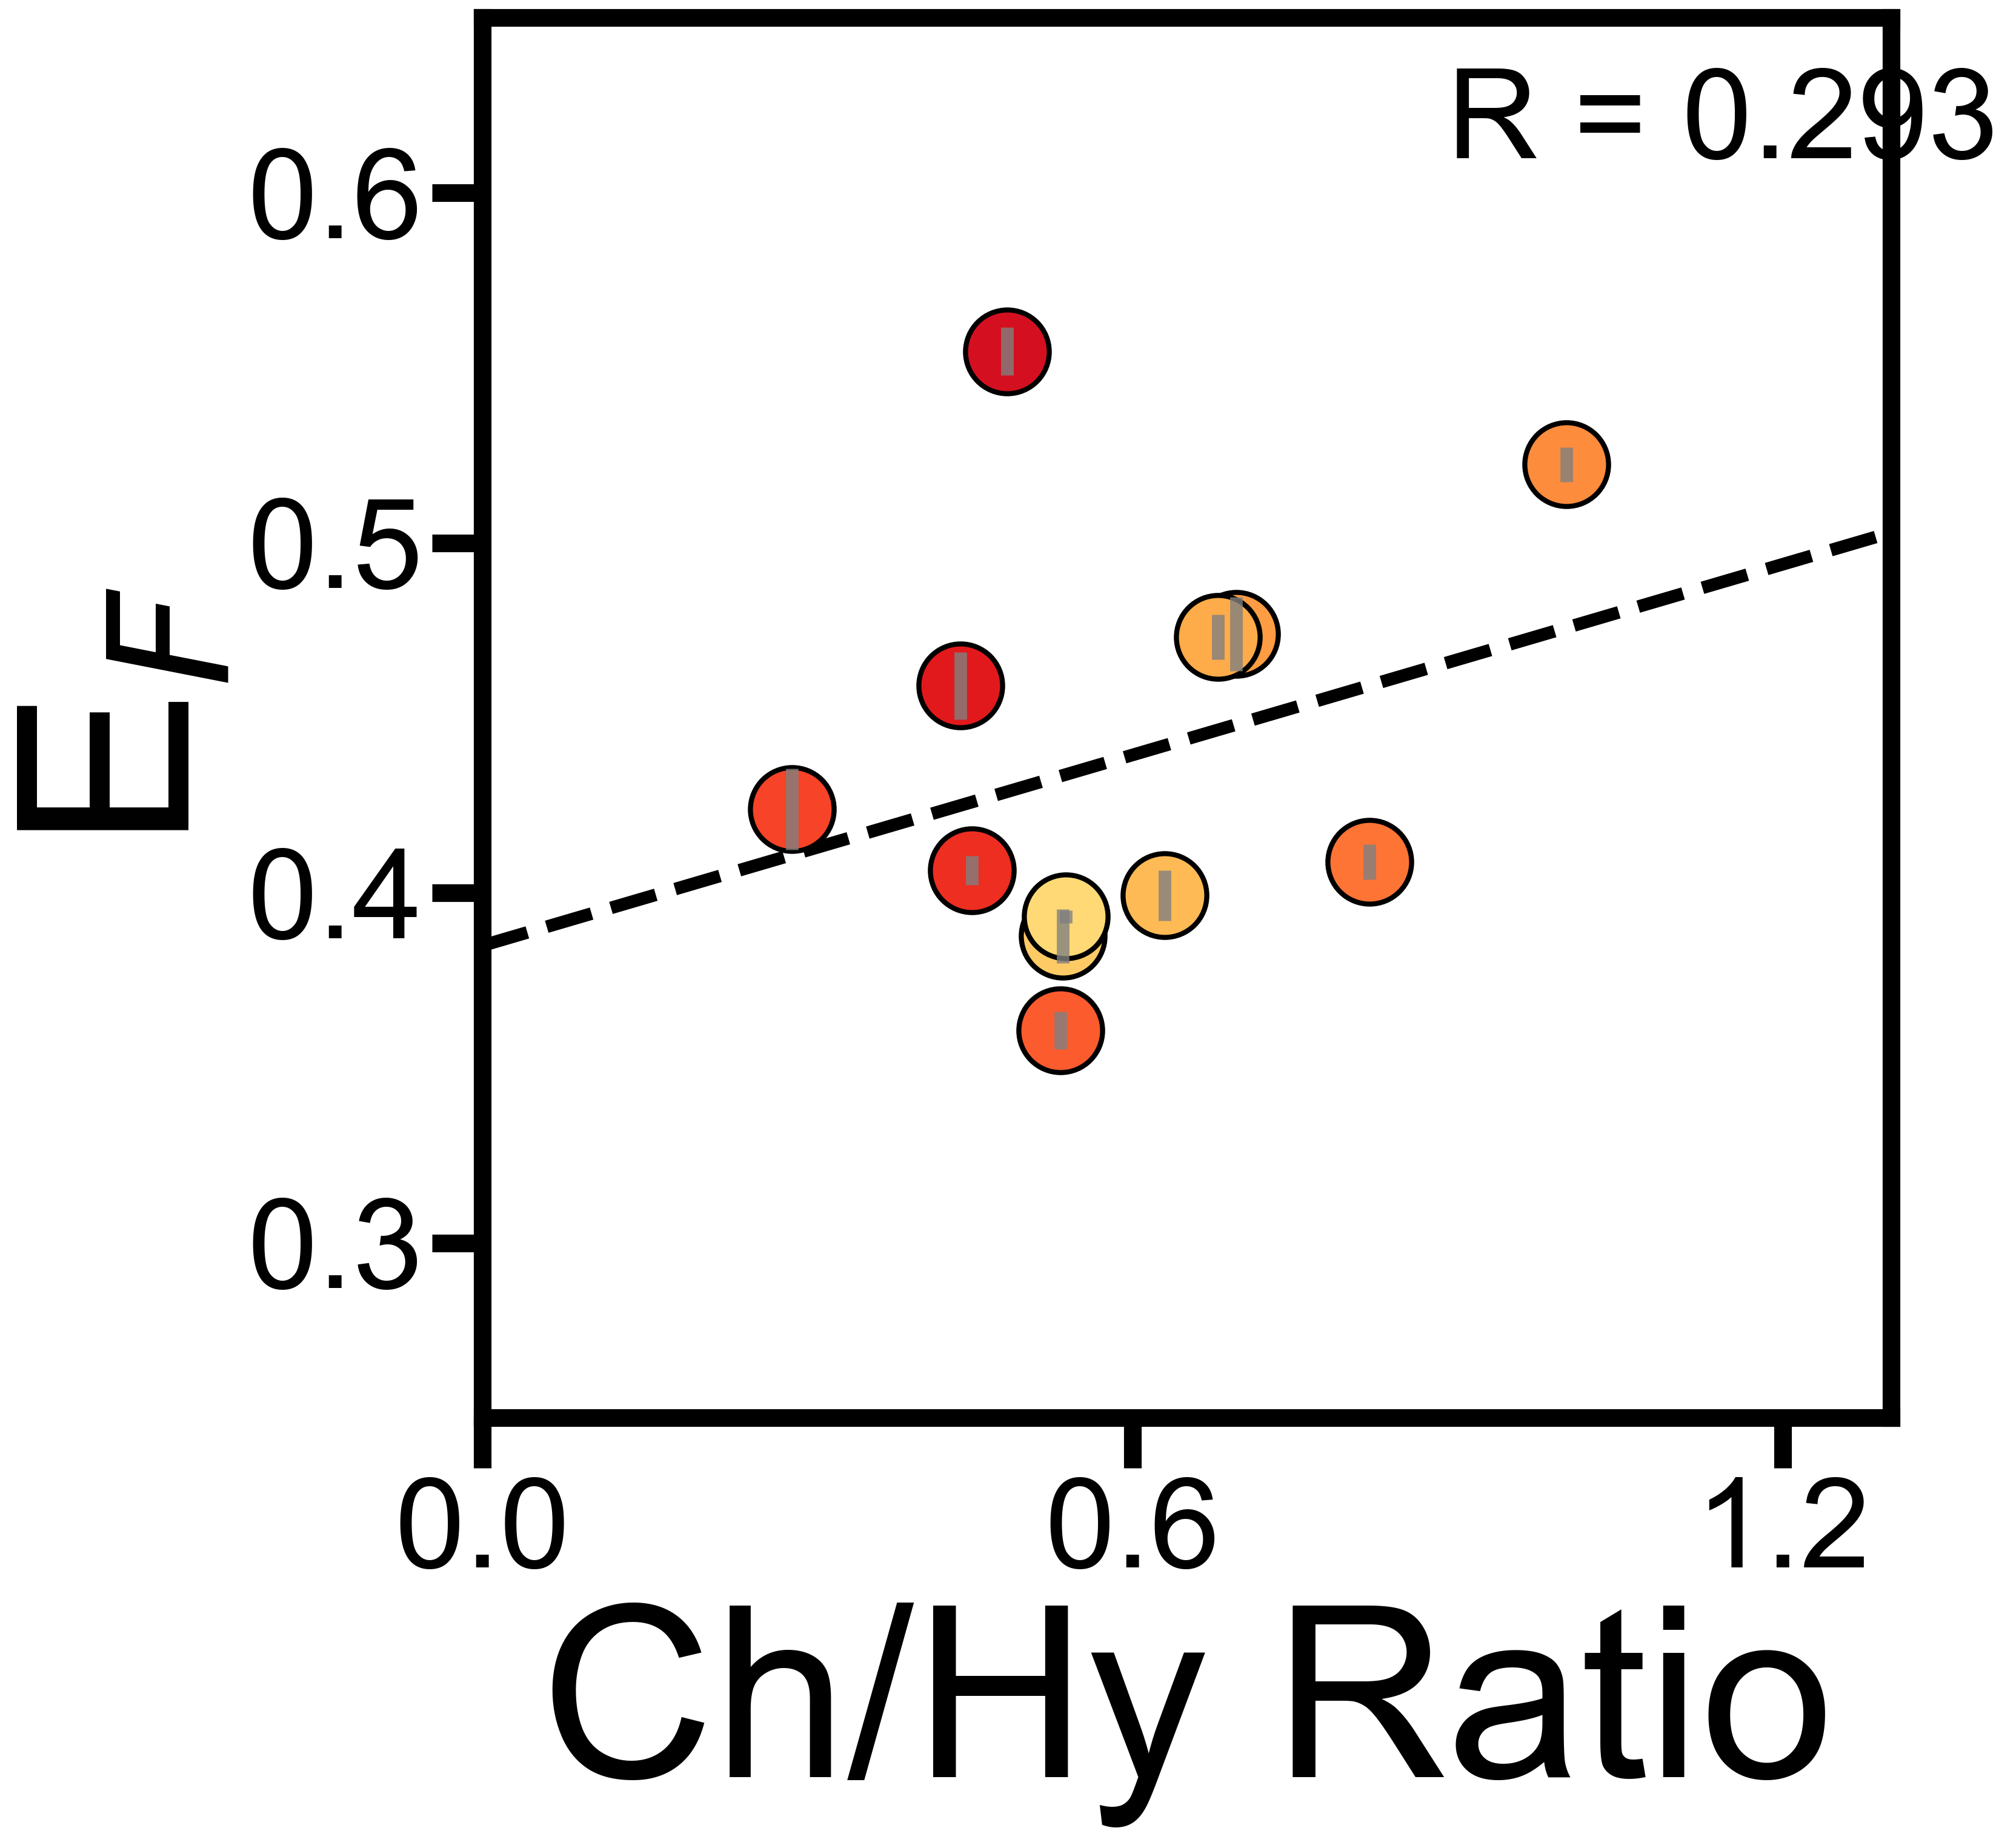

In [194]:
#test_df = plot_df.loc[plot_df['construct'] != 1]
comapre_list = ['ch/hy-ratio']
for i in comapre_list:
    plot_scatter(plot_df, i)

In [196]:
plot_df.to_pickle(r'W:\OneDrive\Virus\Paper1\processed_csvs\charge_hydro-ratio.pkl')

In [74]:
from cider_predictions import evaluate_sequence_features
import pandas as pd

In [75]:
df2 = pd.read_csv(r'W:\OneDrive\Virus\Paper1\processed_csvs\e1a_full_length_residues.csv').iloc[:, 1:]
"".join(df2.iloc[0: 10, 0].tolist())

'MRHIICHGGV'

In [76]:
df2

,Res,Index,Disorder,ppLDDT,sequence
0,M,1,0.694,62.096,E1A
1,R,2,0.636,70.310,E1A
2,H,3,0.538,71.970,E1A
3,I,4,0.420,72.769,E1A
4,I,5,0.333,73.453,E1A
...,...,...,...,...,...
284,K,285,0.812,53.536,E1A
285,R,286,0.836,49.625,E1A
286,P,287,0.801,48.093,E1A
287,R,288,0.750,46.009,E1A


In [80]:
def get_subseq_features(df, seq_spacer: int=10, sequence_column: str="Res"):
    iterations = int(np.ceil(len(df)/seq_spacer))
    iterator_df = df.copy()
    
    df.columns = df.columns.str.strip()
    
    columns = df.columns
    average_ppLDDT = [] if 'ppLDDT' in columns else False
    sequences = []

    position = 1
    for i in range(iterations):
        if len(iterator_df) >= seq_spacer:
            seq_df = iterator_df.iloc[0:seq_spacer]
            iterator_df =iterator_df.iloc[seq_spacer:]
        else:
            seq_df = iterator_df.iloc[0:len(iterator_df)]
            
        sequence = "".join(seq_df[sequence_column].tolist())
        sequences.append(sequence)
        
        if type(average_ppLDDT) == list:
            average_ppLDDT.append(seq_df['ppLDDT'].mean())
        
    sequence_df = evaluate_sequence_features(sequences)
    if not average_ppLDDT:
        return sequence_df
    else:
        sequence_df['average_ppLDDT'] = average_ppLDDT
        return sequence_df

In [81]:
import numpy as np
evaluated_df = get_subseq_features(df2)

In [82]:
evaluated_df

,sequence,FCR,NCPR,mean_hydropathy,kappa,SCD,fraction_disorder_promoting,countPos,countNeut,countNeg,countAro,isoelectric_point,Omega,valines,average_ppLDDT
0,MRHIICHGGV,0.100000,0.100000,5.090000,0.941176,0.000000,0.500000,1,9,0,0,10.500000,0.884658,1,72.200300
1,ITEEMAASLL,0.200000,-0.200000,5.410000,0.854545,0.100000,0.600000,0,8,2,0,1.750000,0.560746,0,82.675300
2,DQLIEEVLAD,0.400000,-0.400000,4.560000,0.043478,1.247214,0.600000,0,6,4,0,1.750000,0.006553,1,85.006200
3,NLPPPSHFEP,0.100000,-0.100000,3.420000,0.941176,0.000000,0.700000,0,9,1,1,5.250000,0.003471,0,69.070900
4,PTLHELYDLD,0.300000,-0.300000,3.910000,0.230000,0.538233,0.600000,0,7,3,1,3.718750,0.125203,0,65.827700
5,VTAPEDPNEE,0.400000,-0.400000,2.960000,0.253623,0.996812,0.800000,0,6,4,0,1.750000,0.242620,1,56.914100
6,AVSQIFPDSV,0.100000,-0.100000,5.230000,0.882353,0.000000,0.600000,0,9,1,1,1.750000,0.560746,2,58.911500
7,MLAVQEGIDL,0.200000,-0.200000,5.410000,0.454545,0.173205,0.500000,0,8,2,0,1.750000,0.239139,1,64.576100
8,LTFPPAPGSP,0.000000,0.000000,4.510000,NaN,0.000000,0.800000,0,10,0,1,7.000000,0.004087,0,57.106500
9,EPPHLSRQPE,0.300000,-0.100000,2.500000,0.194805,-0.118154,0.900000,1,7,2,0,5.250000,0.035757,0,47.163200


In [83]:
lin_space = np.linspace(0.2, len(evaluated_df)+.2, len(evaluated_df))
tile_space = np.linspace(3.25, 25.25 , len(comp_df))
df_space = np.linspace(0.2, len(df)+.2, len(df))

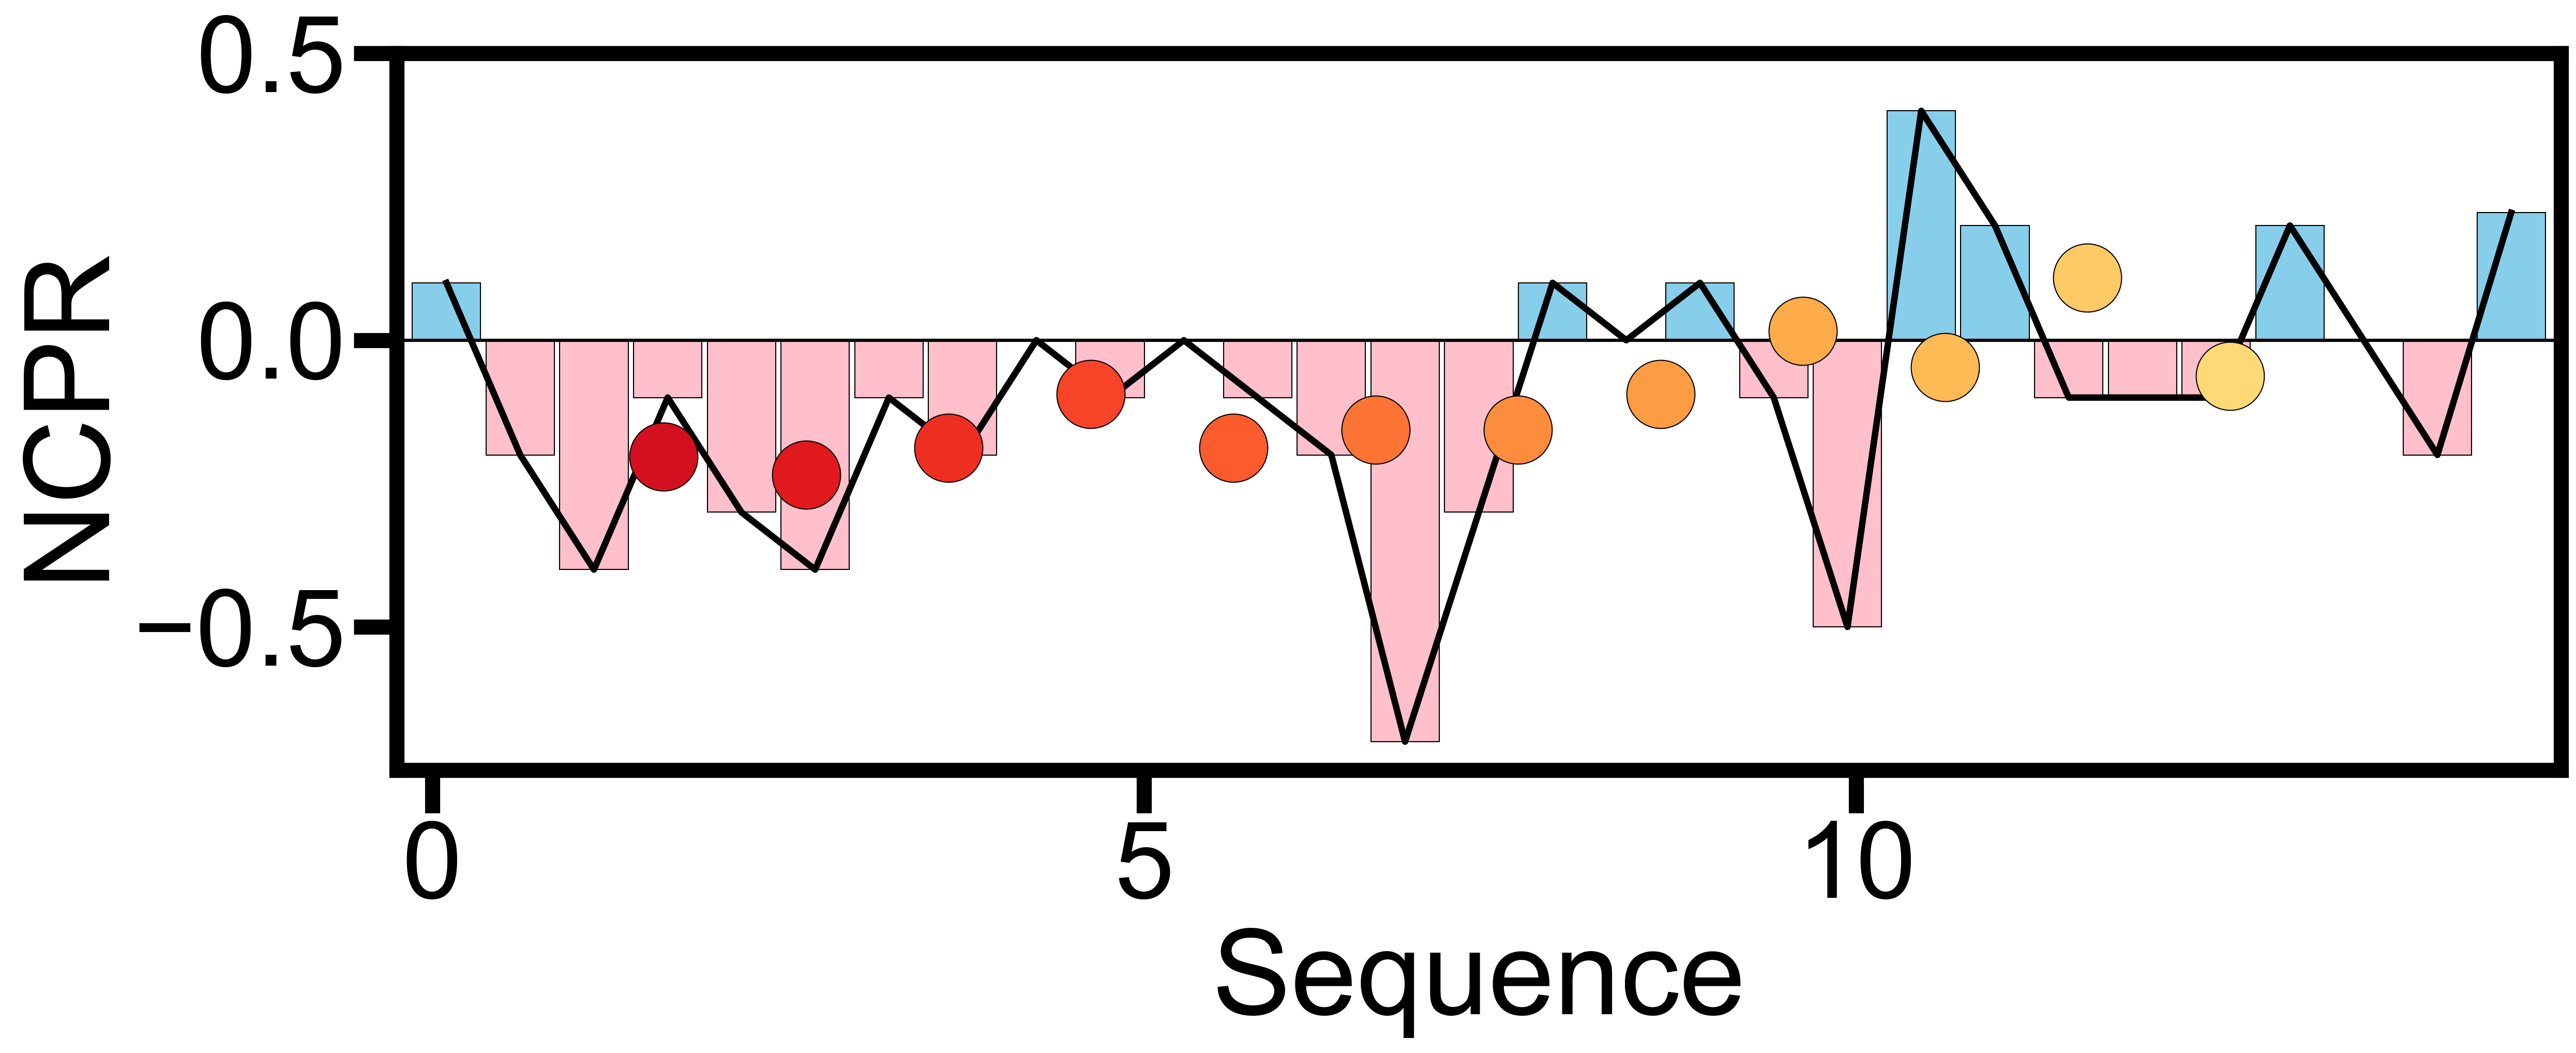

In [84]:
fig, ax = plt.subplots(figsize=(18, 6))
colors = np.where(evaluated_df['NCPR'] >0, 'skyblue', 'pink')

ax.bar(lin_space/2, evaluated_df['NCPR'], width=0.48, color=colors, zorder=2, edgecolor='k', linewidth=0.5)
ax.plot(lin_space/2, evaluated_df['NCPR'], linewidth=3, color = 'k')

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.7, 0.25, N)))

comp_df = comp_df.sort_values('construct')
for i, row in enumerate(comp_df['NCPR']):
    posit = tile_space[i]/2
    ax.scatter(posit, row, s=1000, edgecolor='k', linewidth=0.5, zorder=3)
    
ax.axhline(0, c='k')
ax.set_ylim(-0.75, 0.5)

ax.set_ylabel('NCPR')
ax.set_xlabel('Sequence')

#new_ax = ax.twinx()

#y = 'FCR'
#colors = np.where(evaluated_df[y] >0, 'lightseagreen', 'purple')

#new_ax.bar(lin_space/2, evaluated_df[y], width=0.48, color=colors, edgecolor='k', linewidth=0.5)

#new_ax.set_yticks([0.2, 0.6])
#new_ax.set_ylim(0, 0.8)
#new_ax.set_ylabel(y)

#new_ax.patch.set_visible(False)  # transparent background of the top axes
#ax.set_zorder(new_ax.get_zorder() + 1)  # bring ax in front
#ax.patch.set_visible(False)

#new_ax.set_zorder(1)
#ax.set_zorder(2)
#fig.patch.set_alpha(0)
plt.xlim(-0.25,14.95)
plt.savefig(r'W:/OneDrive/Virus/Paper1/New_fig/computational_comparison/NCPR.svg', format='svg', bbox_inches='tight')
# after creating ax and new_ax


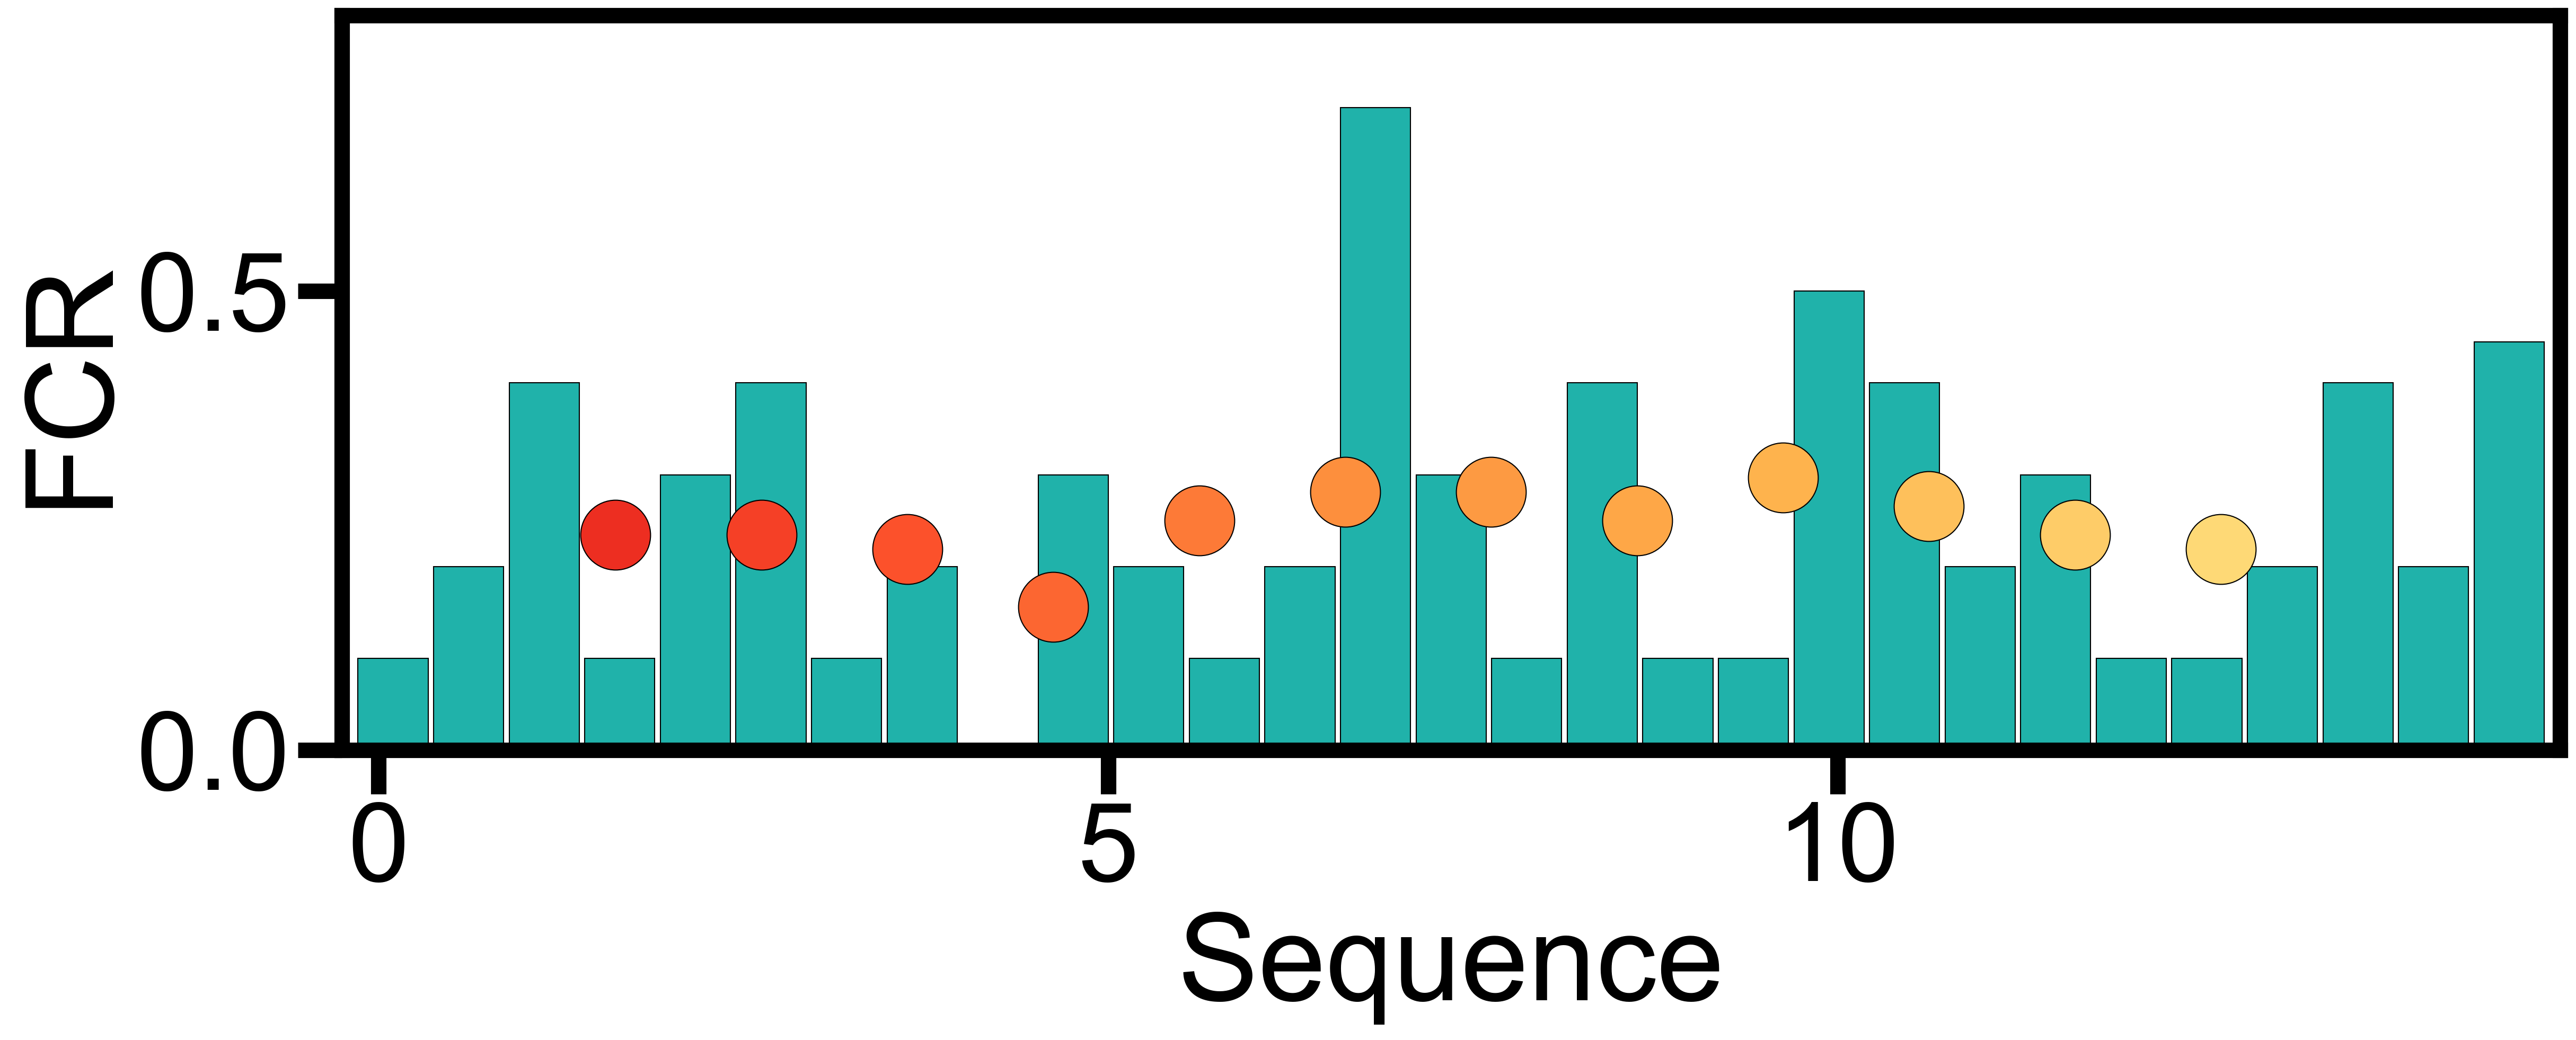

In [85]:
y = 'FCR'

fig, ax = plt.subplots(figsize=(18, 6))
colors = np.where(evaluated_df[y] >0, 'lightseagreen', 'purple')

plt.bar(lin_space/2, evaluated_df[y], width=0.48, color=colors, zorder=2, edgecolor='k', linewidth=0.5)

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.7, 0.25, N)))

comp_df = comp_df.sort_values('construct')
for i, row in enumerate(comp_df[y]):
    posit = tile_space[i]/2
    plt.scatter(posit, row, s=1000, edgecolor='k', linewidth=0.5, zorder=3)
    
#plt.axhline(0, c='k')
plt.ylim(0, 0.8)

plt.ylabel(y)
plt.xlabel('Sequence')
plt.xlim(-0.25,14.95)
plt.savefig(r'W:/OneDrive/Virus/Paper1/New_fig/computational_comparison/FCR.svg', format='svg', bbox_inches='tight')

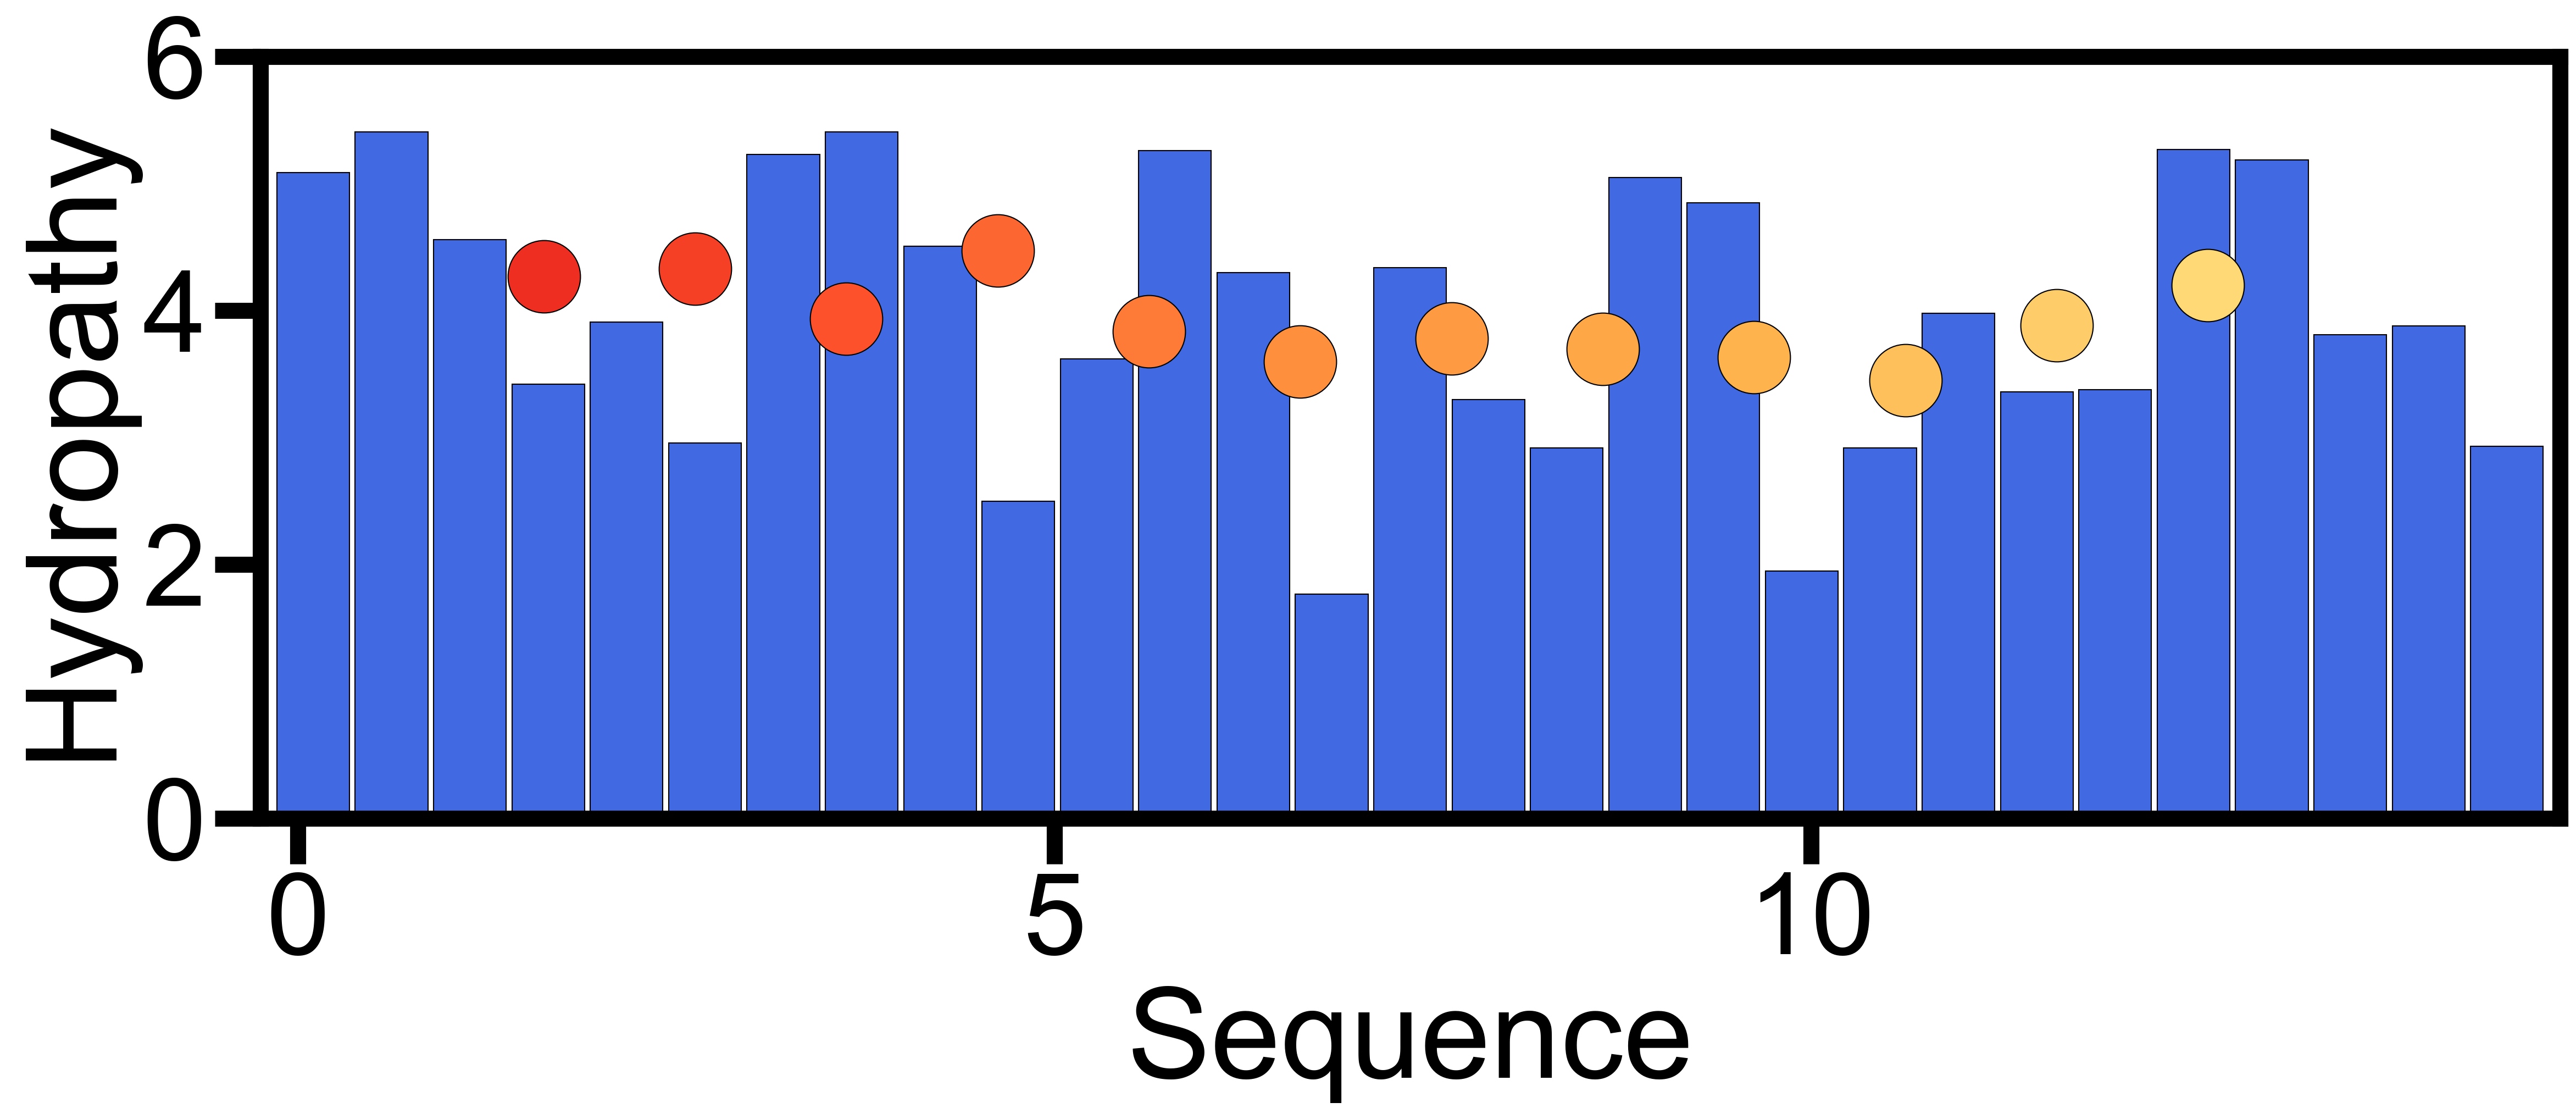

In [86]:

y = 'mean_hydropathy'

fig, ax = plt.subplots(figsize=(18, 6))
colors = np.where(evaluated_df[y] >0, 'royalblue', 'violet')

plt.bar(lin_space/2, evaluated_df[y], width=0.48, color=colors, zorder=2, edgecolor='k', linewidth=0.5)

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.7, 0.25, N)))

comp_df = comp_df.sort_values('construct')
for i, row in enumerate(comp_df[y]):
    posit = tile_space[i]/2
    plt.scatter(posit, row, s=1000, edgecolor='k', linewidth=0.5, zorder=3)
    
#plt.axhline(0, c='k')
plt.ylim(0, 6)
plt.xlim(-0.25,14.95)
plt.ylabel('Hydropathy')
plt.xlabel('Sequence')
plt.savefig(r'W:/OneDrive/Virus/Paper1/New_fig/computational_comparison/hydropathy.svg', format='svg', bbox_inches='tight')

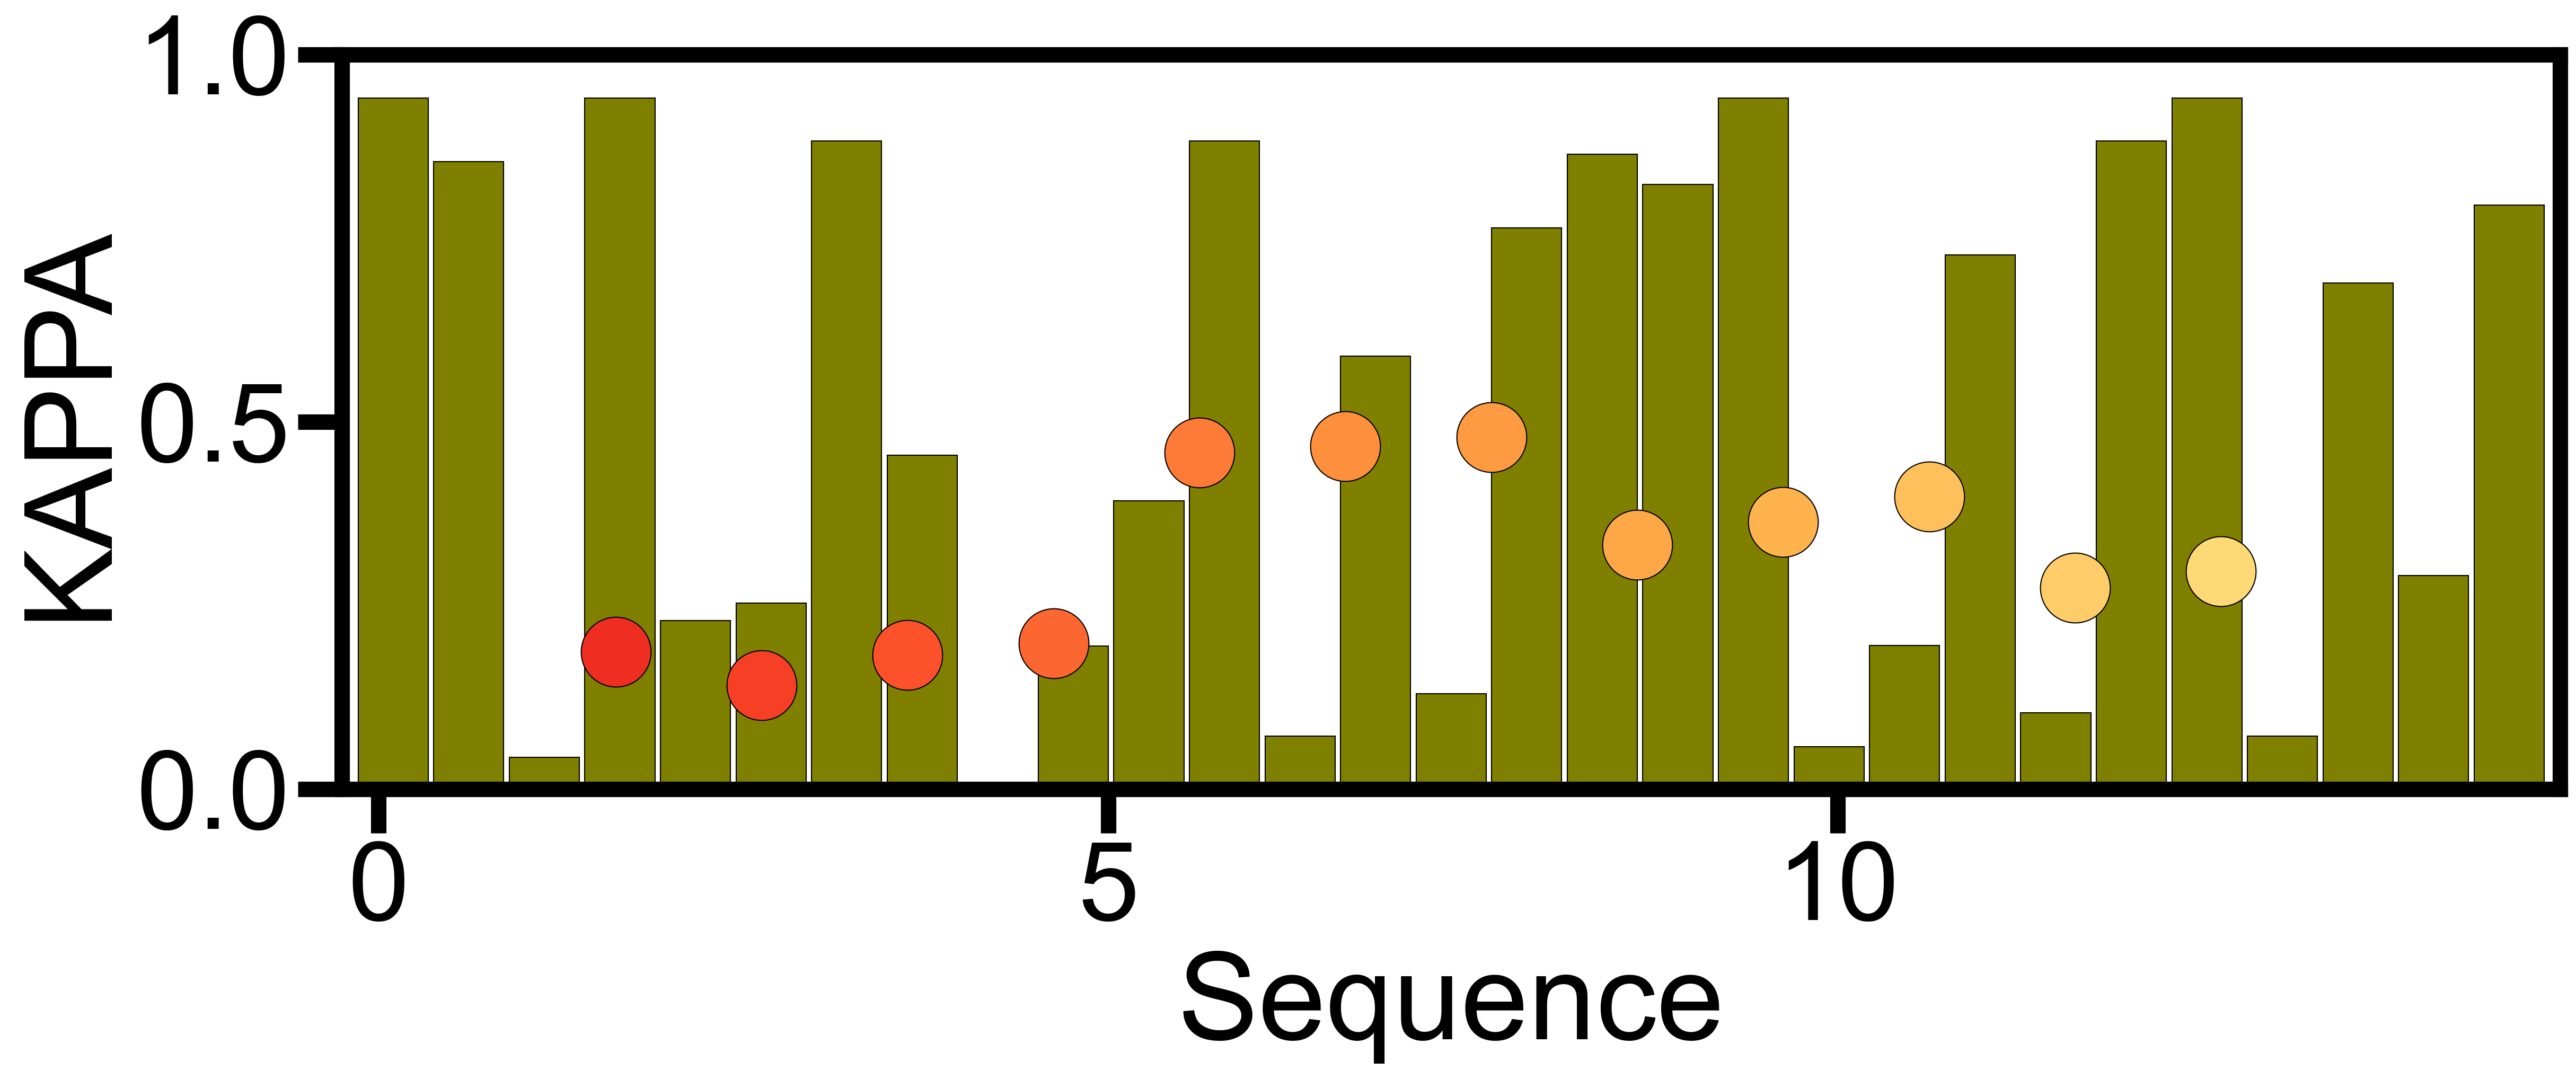

In [87]:
y = 'kappa'

fig, ax = plt.subplots(figsize=(18, 6))
colors = np.where(evaluated_df[y] >0, 'olive', 'violet')

plt.bar(lin_space/2, evaluated_df[y], width=0.48, color=colors, zorder=2, edgecolor='k', linewidth=0.5)

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.7, 0.25, N)))

comp_df = comp_df.sort_values('construct')
for i, row in enumerate(comp_df[y]):
    posit = tile_space[i]/2
    plt.scatter(posit, row, s=1000, edgecolor='k', linewidth=0.5, zorder=3)
    
#plt.axhline(0, c='k')
plt.ylim(0, 1)
plt.xlim(-0.25,14.95)

plt.ylabel('KAPPA')
plt.xlabel('Sequence')
plt.savefig(r'W:/OneDrive/Virus/Paper1/New_fig/computational_comparison/KAPPA.svg', format='svg', bbox_inches='tight')

In [98]:
df2.columns
seq_space = (0, 11, 289)

   Disorder   Index    sequence  start  end  middle construct
0  0.424094    32.5     E1A1-64      0   64    32.0         1
0  0.542906    52.5    E1A21-84     20   84    52.0         2
0  0.707062    72.5   E1A41-104     40  104    72.0         3
0  0.738734    92.5   E1A61-124     60  124    92.0         4
0  0.772312   112.5   E1A81-144     80  144   112.0         5
0  0.602766   132.5  E1A101-164    100  164   132.0         6
0  0.397141   152.5  E1A121-184    120  184   152.0         7
0  0.434562   172.5  E1A141-204    140  204   172.0         8
0  0.617109   192.5  E1A161-224    160  224   192.0         9
0  0.852672   212.5  E1A181-244    180  244   212.0        10
0  0.848078   232.5  E1A201-264    200  264   232.0        11
0  0.773766   252.5  E1A221-284    220  284   252.0        12


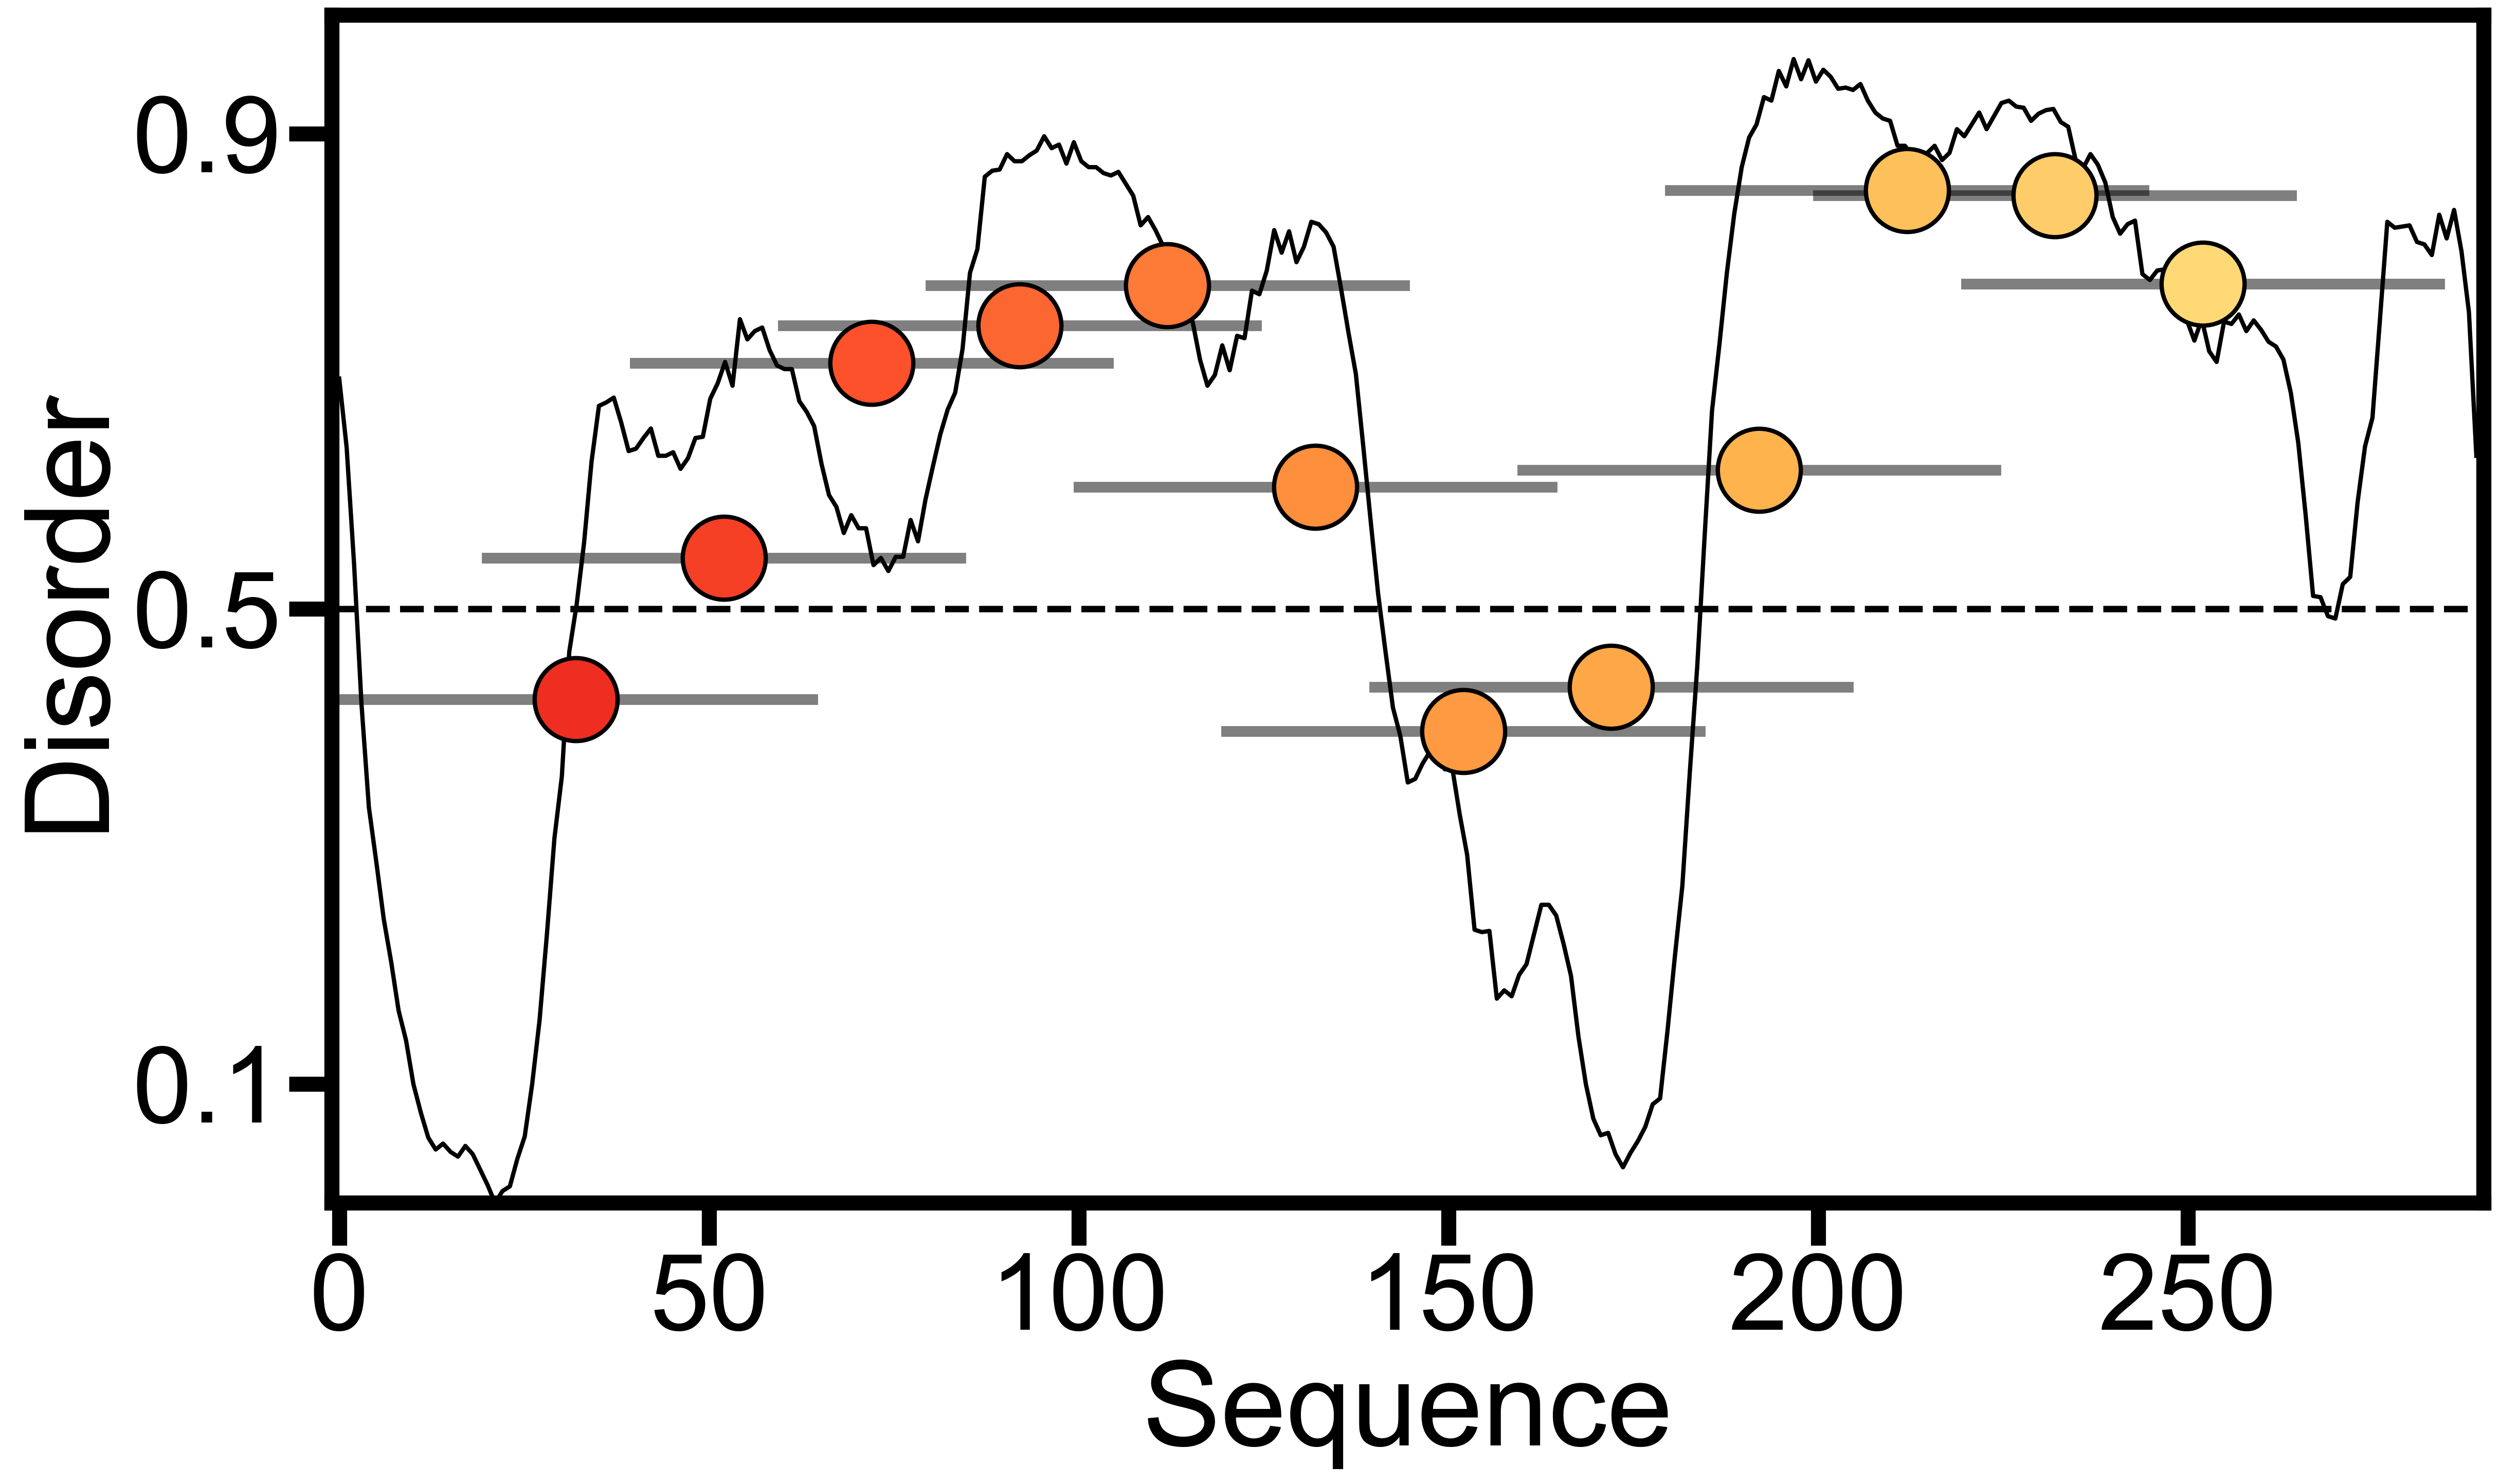

In [104]:

fig, ax2 = plt.subplots(figsize=(18, 10))

ax= ax2.twinx()
#ax.plot(df_space, df[y], color='b',  linewidth=2, )
seq_space = np.linspace(0, 289, 289)
ax2.plot(seq_space, df2['Disorder'], color='k', linewidth=2)

N=12


full_length_prection = pd.DataFrame()
for i in range(12):
    start = i*20
    end = start+64
    tmp= df2[start:end]
    tmp_disorder = pd.DataFrame({'Disorder':[tmp['Disorder'].mean()],
                                 ' Index': [tmp['Index'].median()]})
    tmp_disorder['sequence'] = 'E1A'+str(start+1)+'-'+str(end)
    
    tmp_disorder['start'] = start
    tmp_disorder['end'] = end
    tmp_disorder['middle'] = (start+end)/2
    tmp_disorder['construct'] = str(i+1)
    
    full_length_prection = pd.concat([full_length_prection, tmp_disorder])

comp_df = full_length_prection.sort_values('start')
print(comp_df)
for disorder, posit, start, end in zip(comp_df['Disorder'], comp_df['middle'], comp_df['start'], comp_df['end']):
    ax2.scatter(posit, disorder, s=1500, edgecolor='k', linewidth=2, zorder=3)
    ax2.plot((start, end), (disorder, disorder), c='k', alpha=0.5, zorder=2, linewidth=5)


ax2.axhline(0.5, c='k', linestyle= '--', linewidth=3)
#plt.axhline(0, c='k')
ax.set_ylim(0, 100)
ax2.set_ylim(0,1)
plt.xlim(-1, 290)
ax.set_ylabel('')
ax.set_yticks([])
ax2.set_ylabel('Disorder')
ax2.set_xlabel('Sequence')

ax2.set_yticks([0.1, 0.5, 0.9])
ax.patch.set_visible(False)  # transparent background of the top axes
#ax2.set_zorder(new_ax.get_zorder() + 1)  # bring ax in front
ax2.patch.set_visible(False)
ax2.axhline(0, linestyle='--', c='k')

plt.savefig(r'W:/OneDrive/Virus/Paper1/New_fig/computational_comparison/disorder_ppLDDT_plot.svg', format='svg', bbox_inches='tight')

In [180]:
comp_df.loc[:,'Omega']

0     0.159529
4     0.109102
5     0.113462
6     0.107336
7     0.084289
8     0.102596
9     0.199433
10    0.331464
11    0.317675
1     0.207887
2     0.048379
3     0.035333
Name: Omega, dtype: float64

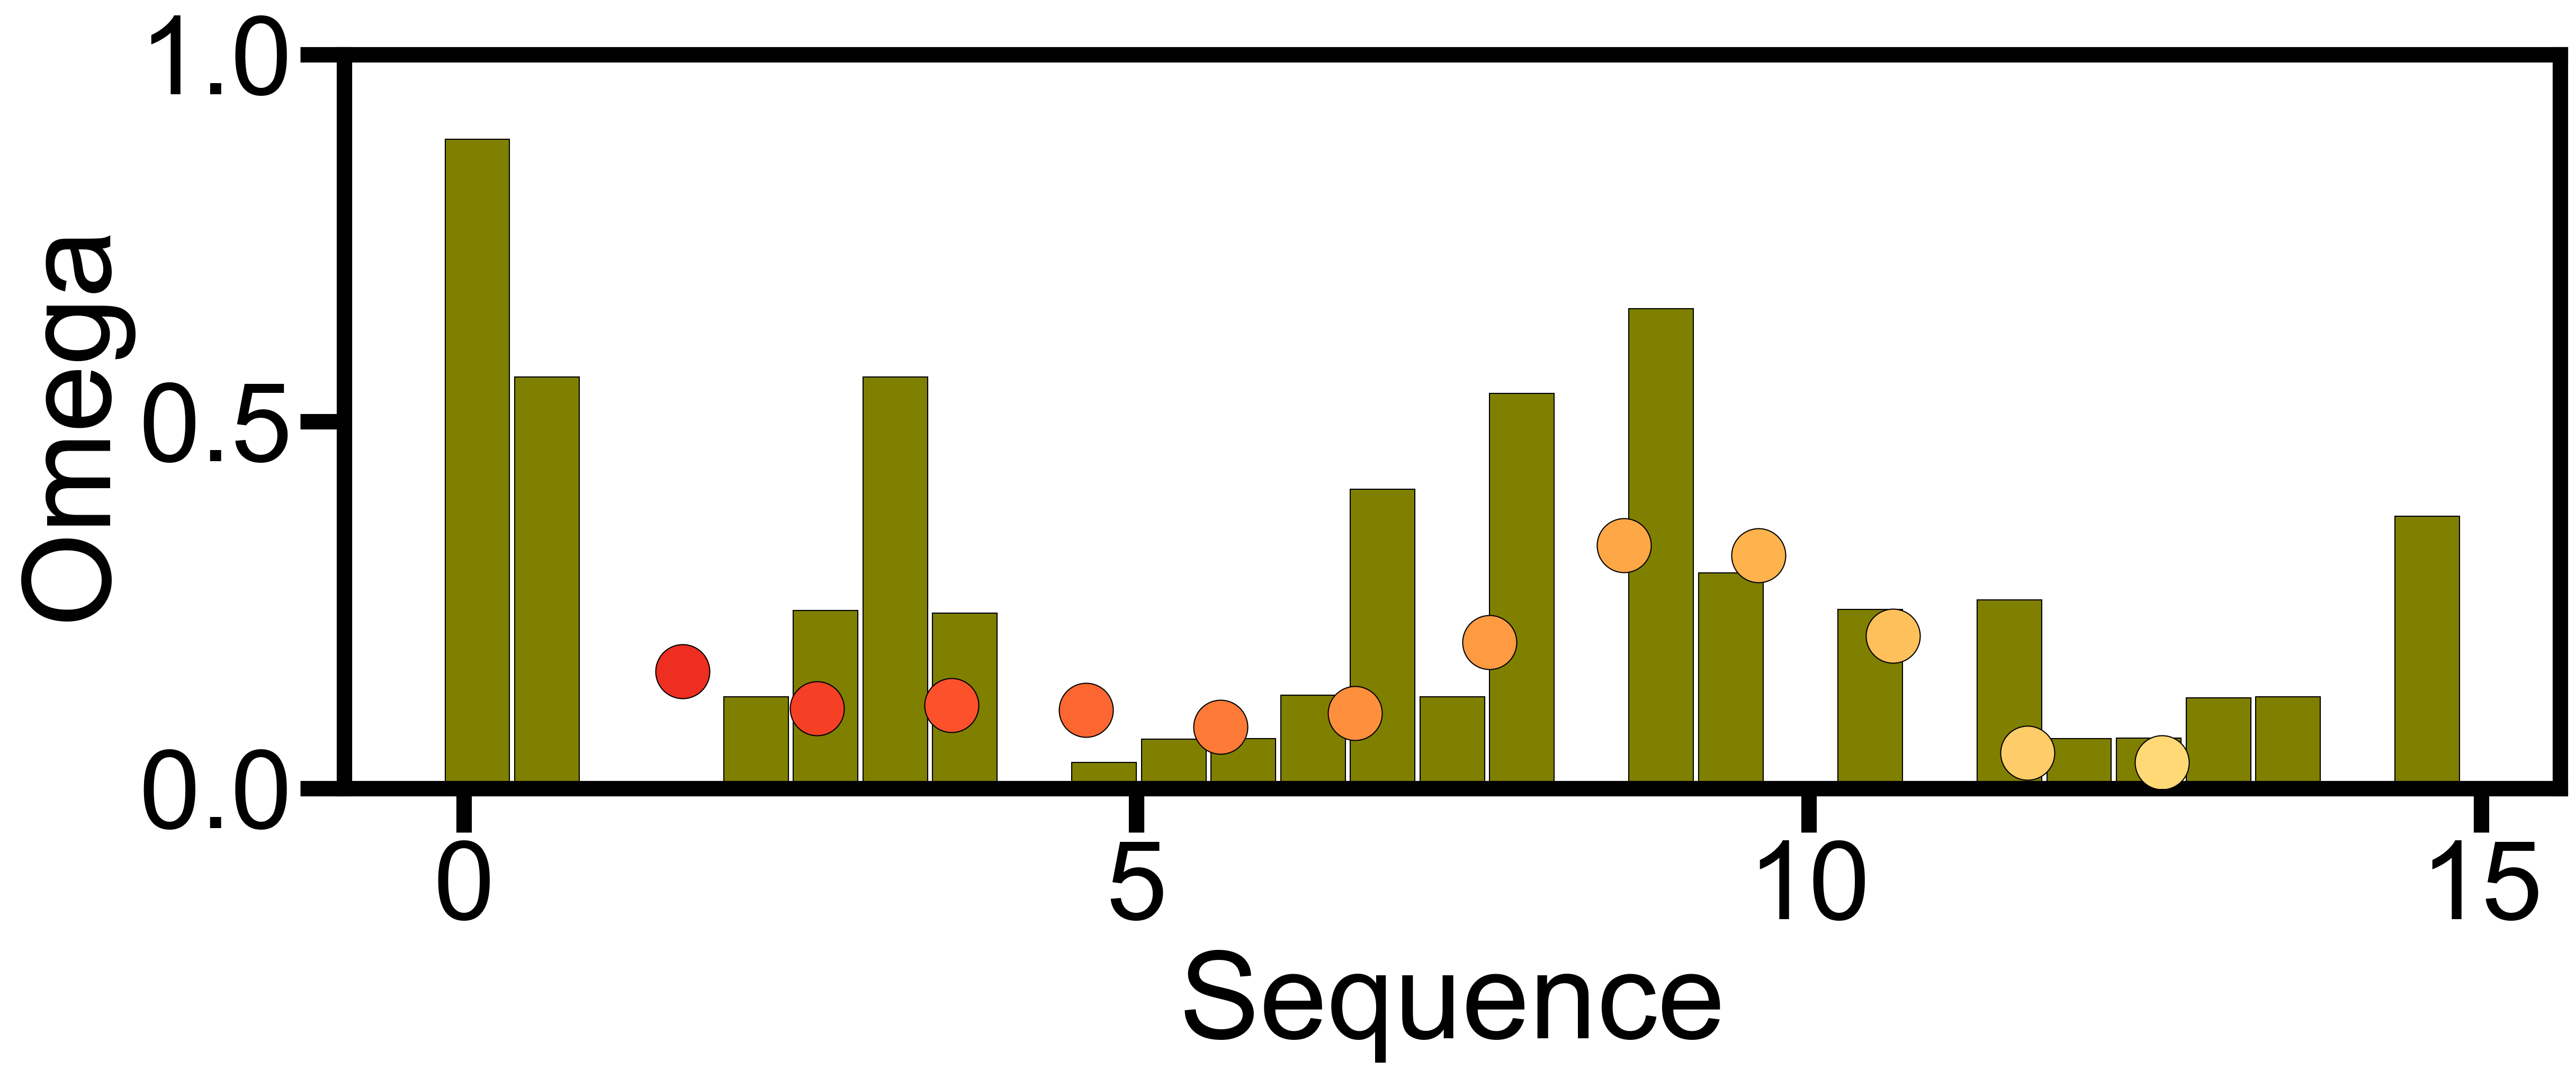

In [181]:
y = 'Omega'

fig, ax = plt.subplots(figsize=(18, 6))
colors = np.where(evaluated_df[y] >0, 'olive', 'violet')

plt.bar(lin_space/2, evaluated_df[y], width=0.48, color=colors, zorder=2, edgecolor='k', linewidth=0.5)

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.7, 0.25, N)))

set_df = set_df.sort_values('construct')
for i, row in enumerate(comp_df.loc[:, y]):
    posit = tile_space[i]/2
    plt.scatter(posit, row, s=600, edgecolor='k', linewidth=0.5, zorder=3)
    
#plt.axhline(0, c='k')
plt.ylim(0, 1)

plt.ylabel('Omega')
plt.xlabel('Sequence')
plt.savefig(r'W:/OneDrive/Virus/Paper1/New_fig/computational_comparison/omega.svg', format='svg', bbox_inches='tight')

Below
[70 31 58]
[0. 0. 0.]
Above
[82 37 66]
[70. 31. 58.]


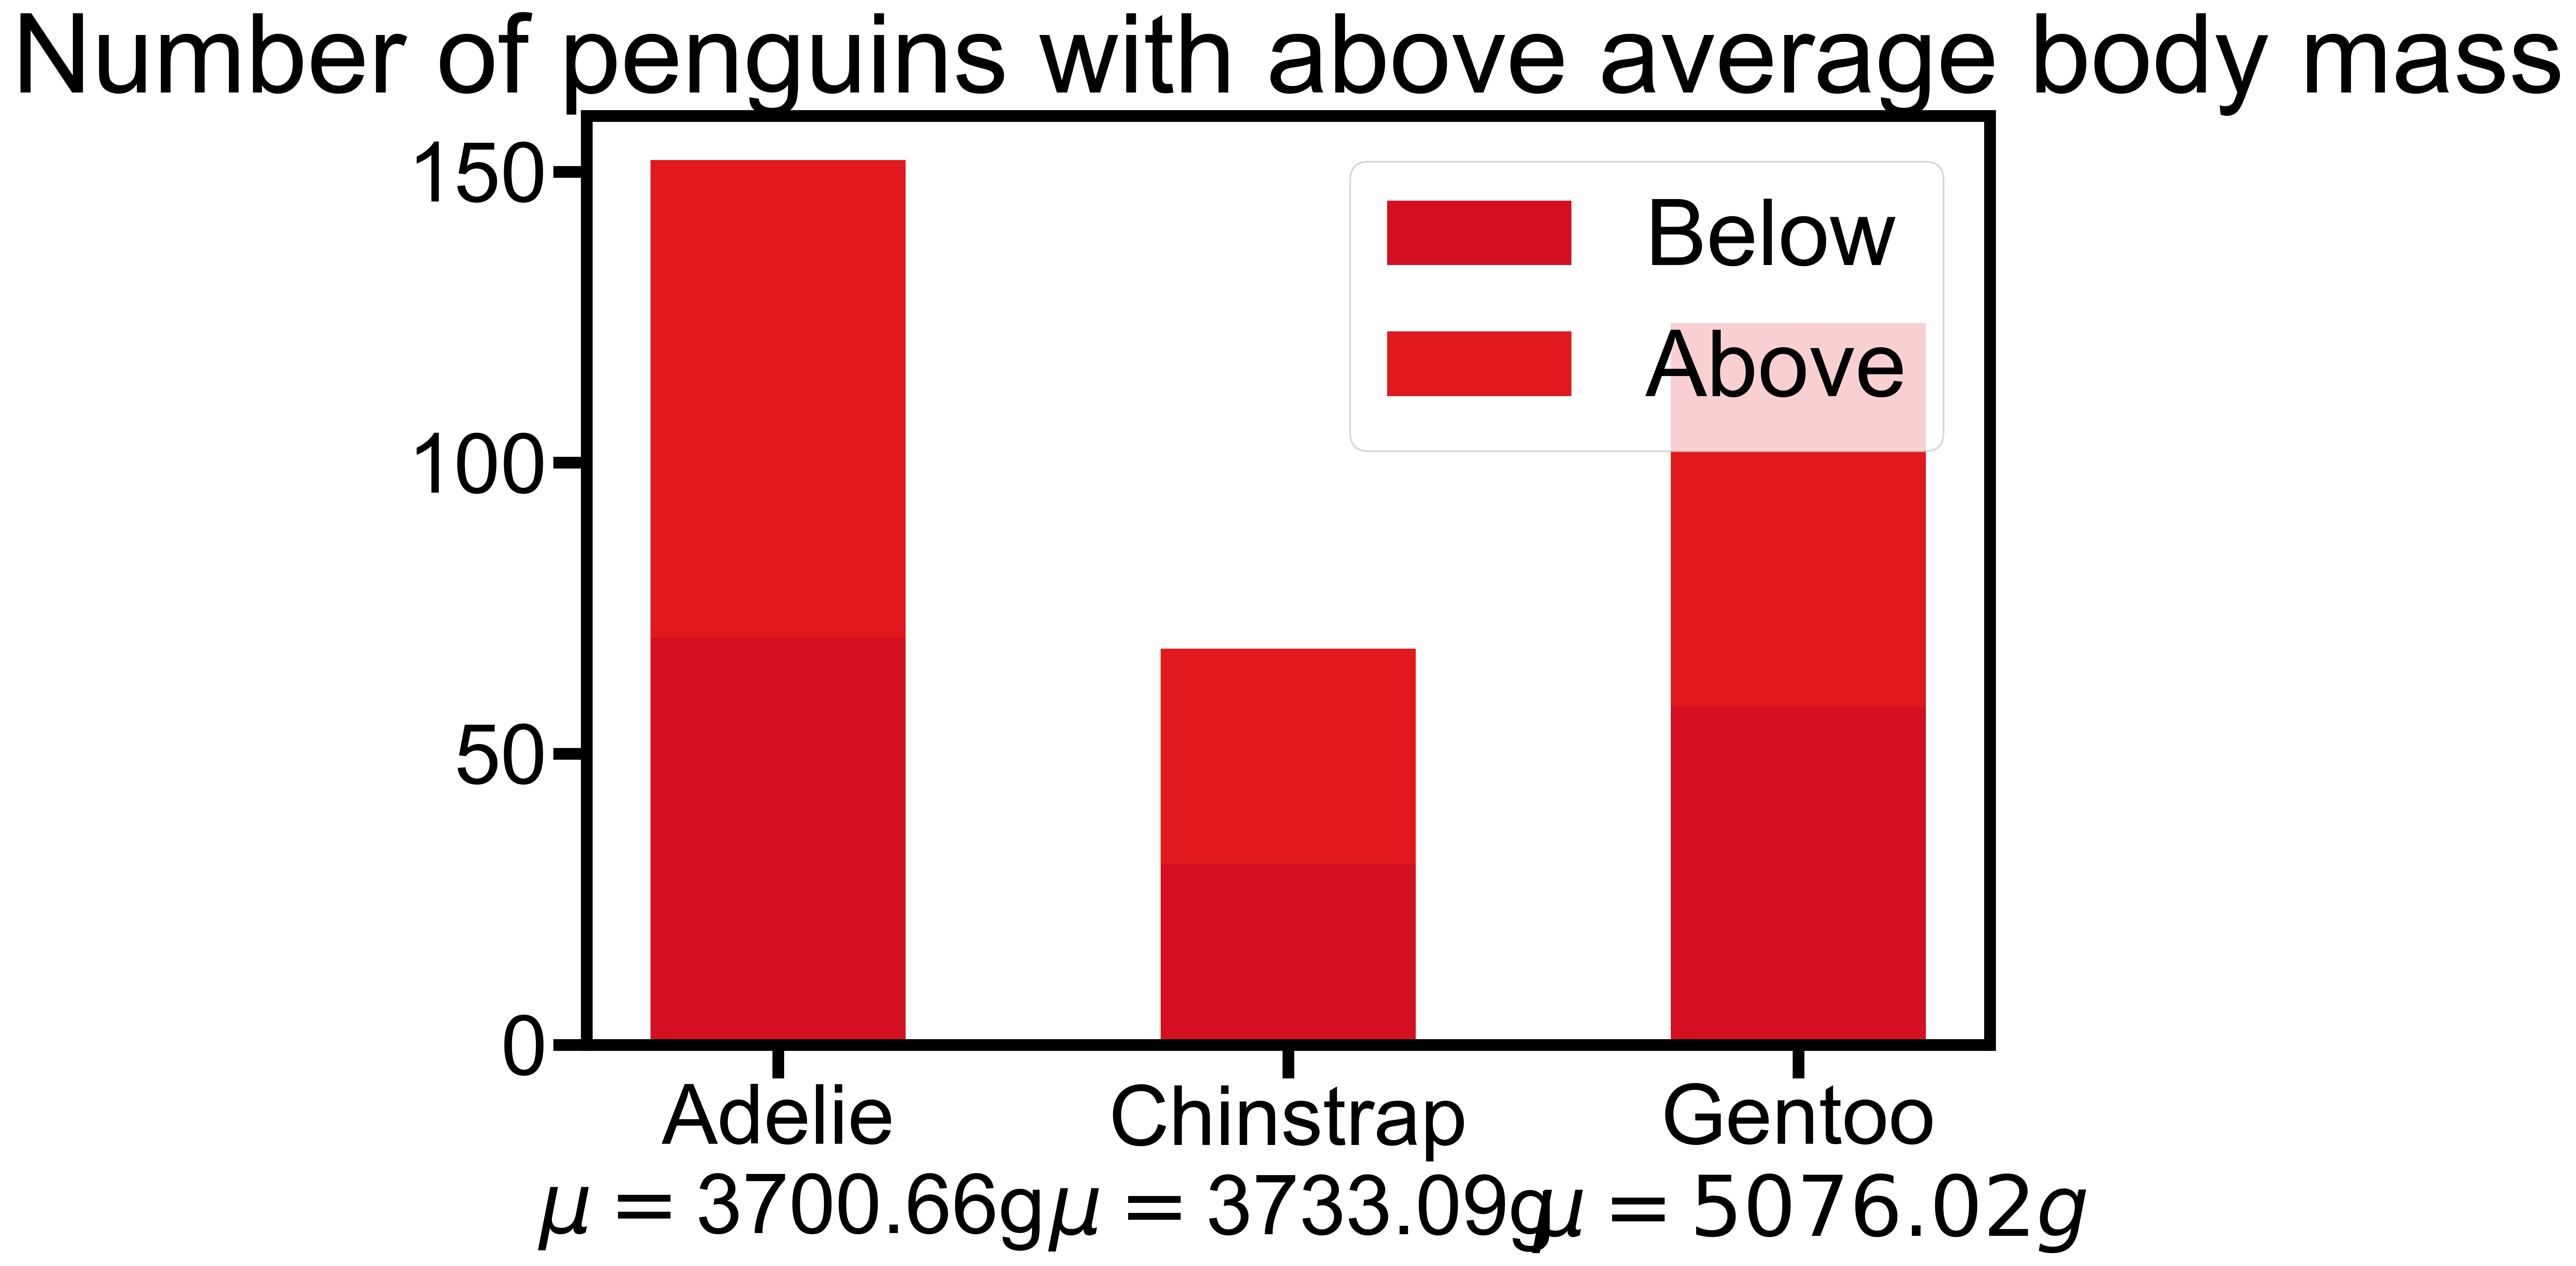

In [251]:
import matplotlib.pyplot as plt
import numpy as np

